# Weighted vs Unweighted Reconstruction Comparison
Side-by-side comparison of reconstructions from weighted and unweighted models

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
from tqdm.auto import tqdm

# Runtime reload
import importlib
import models.autoencoder.bottleneck_models
importlib.reload(models.autoencoder.bottleneck_models)

from data.data_ingestion import collect_files, generate_dataframe
from data.dataloader import create_dataloaders
from models.autoencoder.bottleneck_models import (
    BottleneckEncoder,
    ComplexBottleneckDeconvDecoder,
    BottleneckAE,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Data Setup

In [2]:
root_dir = Path(".")
images_dir = root_dir / "data" / "Images"
mask_path = root_dir / "data" / "masks" / "rmask_ICV.nii"

# Configuration
data_dir = "data/Images"
mask_path = "data/masks/rmask_ICV.nii"
batch_size = 4
unweighted_output_dir = "output/Experiments/BottleneckDeconvTraining"
weighted_output_dir = "output/Experiments/BottleneckDeconvWeightedTraining"
comparison_output_dir = "output/Experiments/WeightedUnweightedComparison"

# Create output directory
os.makedirs(comparison_output_dir, exist_ok=True)

In [3]:
# Prepare data
print("Collecting files...")
included_files, excluded_files = collect_files(data_dir)
print(f"Found {len(included_files)} valid files, excluded {len(excluded_files)} files")

# Generate dataframe
print("Generating dataframe...")
df = generate_dataframe(included_files)

# Create dataloaders
print("Creating dataloaders...")
train_loader, val_loader = create_dataloaders(
    df, batch_size=batch_size, train_split=0.8, 
    on_demand=True, mask_path=mask_path,
    num_workers=2
)

print(f"Data preparation complete. Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}")

Found 2976 valid files, excluded 893 files
Generating dataframe...
Creating dataloaders...

Training set distribution:
label
PD         2035
Control     235
SWEDD       110
Name: count, dtype: int64

Validation set distribution:
label
PD         510
Control     59
SWEDD       27
Name: count, dtype: int64
Using on-demand data loading strategy (lighter on memory but slower)
✅ Brain mask loaded successfully
✅ All 2380 file paths are valid
✅ Brain mask loaded successfully
✅ All 596 file paths are valid
Data preparation complete. Train: 2380, Val: 596


## Model Setup

In [4]:
target_shape = (64, 128, 128)

def build_model(latent_dim=128):
    """Build ComplexBottleneckDeconvDecoder model"""
    model = BottleneckAE(
        BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=(1,1,1)),
        ComplexBottleneckDeconvDecoder(latent_dim=latent_dim, target_shape=target_shape),
    )
    return model.to(device)

## Load All Models

In [5]:
# Load all unweighted trained models from checkpoints
unweighted_models = {}
deconv_latent_dims = [512, 256, 128, 64, 32]

for latent_dim in deconv_latent_dims:
    model_name = f"deconv_lat{latent_dim}"
    checkpoint_path = os.path.join(unweighted_output_dir, model_name, f"{model_name}_best.pth")
    
    if os.path.exists(checkpoint_path):
        print(f"Loading {model_name} from {checkpoint_path}...")
        model = build_model(latent_dim=latent_dim)
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        unweighted_models[model_name] = model.eval()
        print(f"✓ Loaded {model_name}")
    else:
        print(f"✗ Checkpoint not found for {model_name}")

print(f"\nLoaded {len(unweighted_models)} unweighted models")

Loading deconv_lat512 from output/Experiments/BottleneckDeconvTraining/deconv_lat512/deconv_lat512_best.pth...
✓ Loaded deconv_lat512
Loading deconv_lat256 from output/Experiments/BottleneckDeconvTraining/deconv_lat256/deconv_lat256_best.pth...
✓ Loaded deconv_lat256
Loading deconv_lat128 from output/Experiments/BottleneckDeconvTraining/deconv_lat128/deconv_lat128_best.pth...
✓ Loaded deconv_lat128
Loading deconv_lat64 from output/Experiments/BottleneckDeconvTraining/deconv_lat64/deconv_lat64_best.pth...
✓ Loaded deconv_lat64
Loading deconv_lat32 from output/Experiments/BottleneckDeconvTraining/deconv_lat32/deconv_lat32_best.pth...
✓ Loaded deconv_lat32

Loaded 5 unweighted models


In [6]:
# Load all weighted trained models from checkpoints
weighted_models = {}

for latent_dim in deconv_latent_dims:
    model_name = f"deconv_weighted_lat{latent_dim}"
    checkpoint_path = os.path.join(weighted_output_dir, model_name, f"{model_name}_best.pth")
    
    if os.path.exists(checkpoint_path):
        print(f"Loading {model_name} from {checkpoint_path}...")
        model = build_model(latent_dim=latent_dim)
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        weighted_models[model_name] = model.eval()
        print(f"✓ Loaded {model_name}")
    else:
        print(f"✗ Checkpoint not found for {model_name}")

print(f"\nLoaded {len(weighted_models)} weighted models")

Loading deconv_weighted_lat512 from output/Experiments/BottleneckDeconvWeightedTraining/deconv_weighted_lat512/deconv_weighted_lat512_best.pth...
✓ Loaded deconv_weighted_lat512
Loading deconv_weighted_lat256 from output/Experiments/BottleneckDeconvWeightedTraining/deconv_weighted_lat256/deconv_weighted_lat256_best.pth...
✓ Loaded deconv_weighted_lat256
Loading deconv_weighted_lat128 from output/Experiments/BottleneckDeconvWeightedTraining/deconv_weighted_lat128/deconv_weighted_lat128_best.pth...
✓ Loaded deconv_weighted_lat128
Loading deconv_weighted_lat64 from output/Experiments/BottleneckDeconvWeightedTraining/deconv_weighted_lat64/deconv_weighted_lat64_best.pth...
✓ Loaded deconv_weighted_lat64
Loading deconv_weighted_lat32 from output/Experiments/BottleneckDeconvWeightedTraining/deconv_weighted_lat32/deconv_weighted_lat32_best.pth...
✓ Loaded deconv_weighted_lat32

Loaded 5 weighted models


## Get Batch for Visualization

In [9]:
# Get a batch for reconstruction visualization
batch = next(iter(val_loader))
inp = batch['volume'].to(device)
labels = batch['label']

print(f"Input batch shape: {inp.shape}")
print(f"Labels: {labels}")

# Get reconstructions from all unweighted models
unweighted_reconstructions = {}
with torch.no_grad():
    for model_name, model in unweighted_models.items():
        out = model(inp)
        unweighted_reconstructions[model_name] = out

# Get reconstructions from all weighted models
weighted_reconstructions = {}
with torch.no_grad():
    for model_name, model in weighted_models.items():
        out = model(inp)
        weighted_reconstructions[model_name] = out

Input batch shape: torch.Size([4, 1, 64, 128, 128])
Labels: ['PD', 'PD', 'PD', 'Control']


# Visualize side-by-side comparisons for each sample in batch (coronal view)

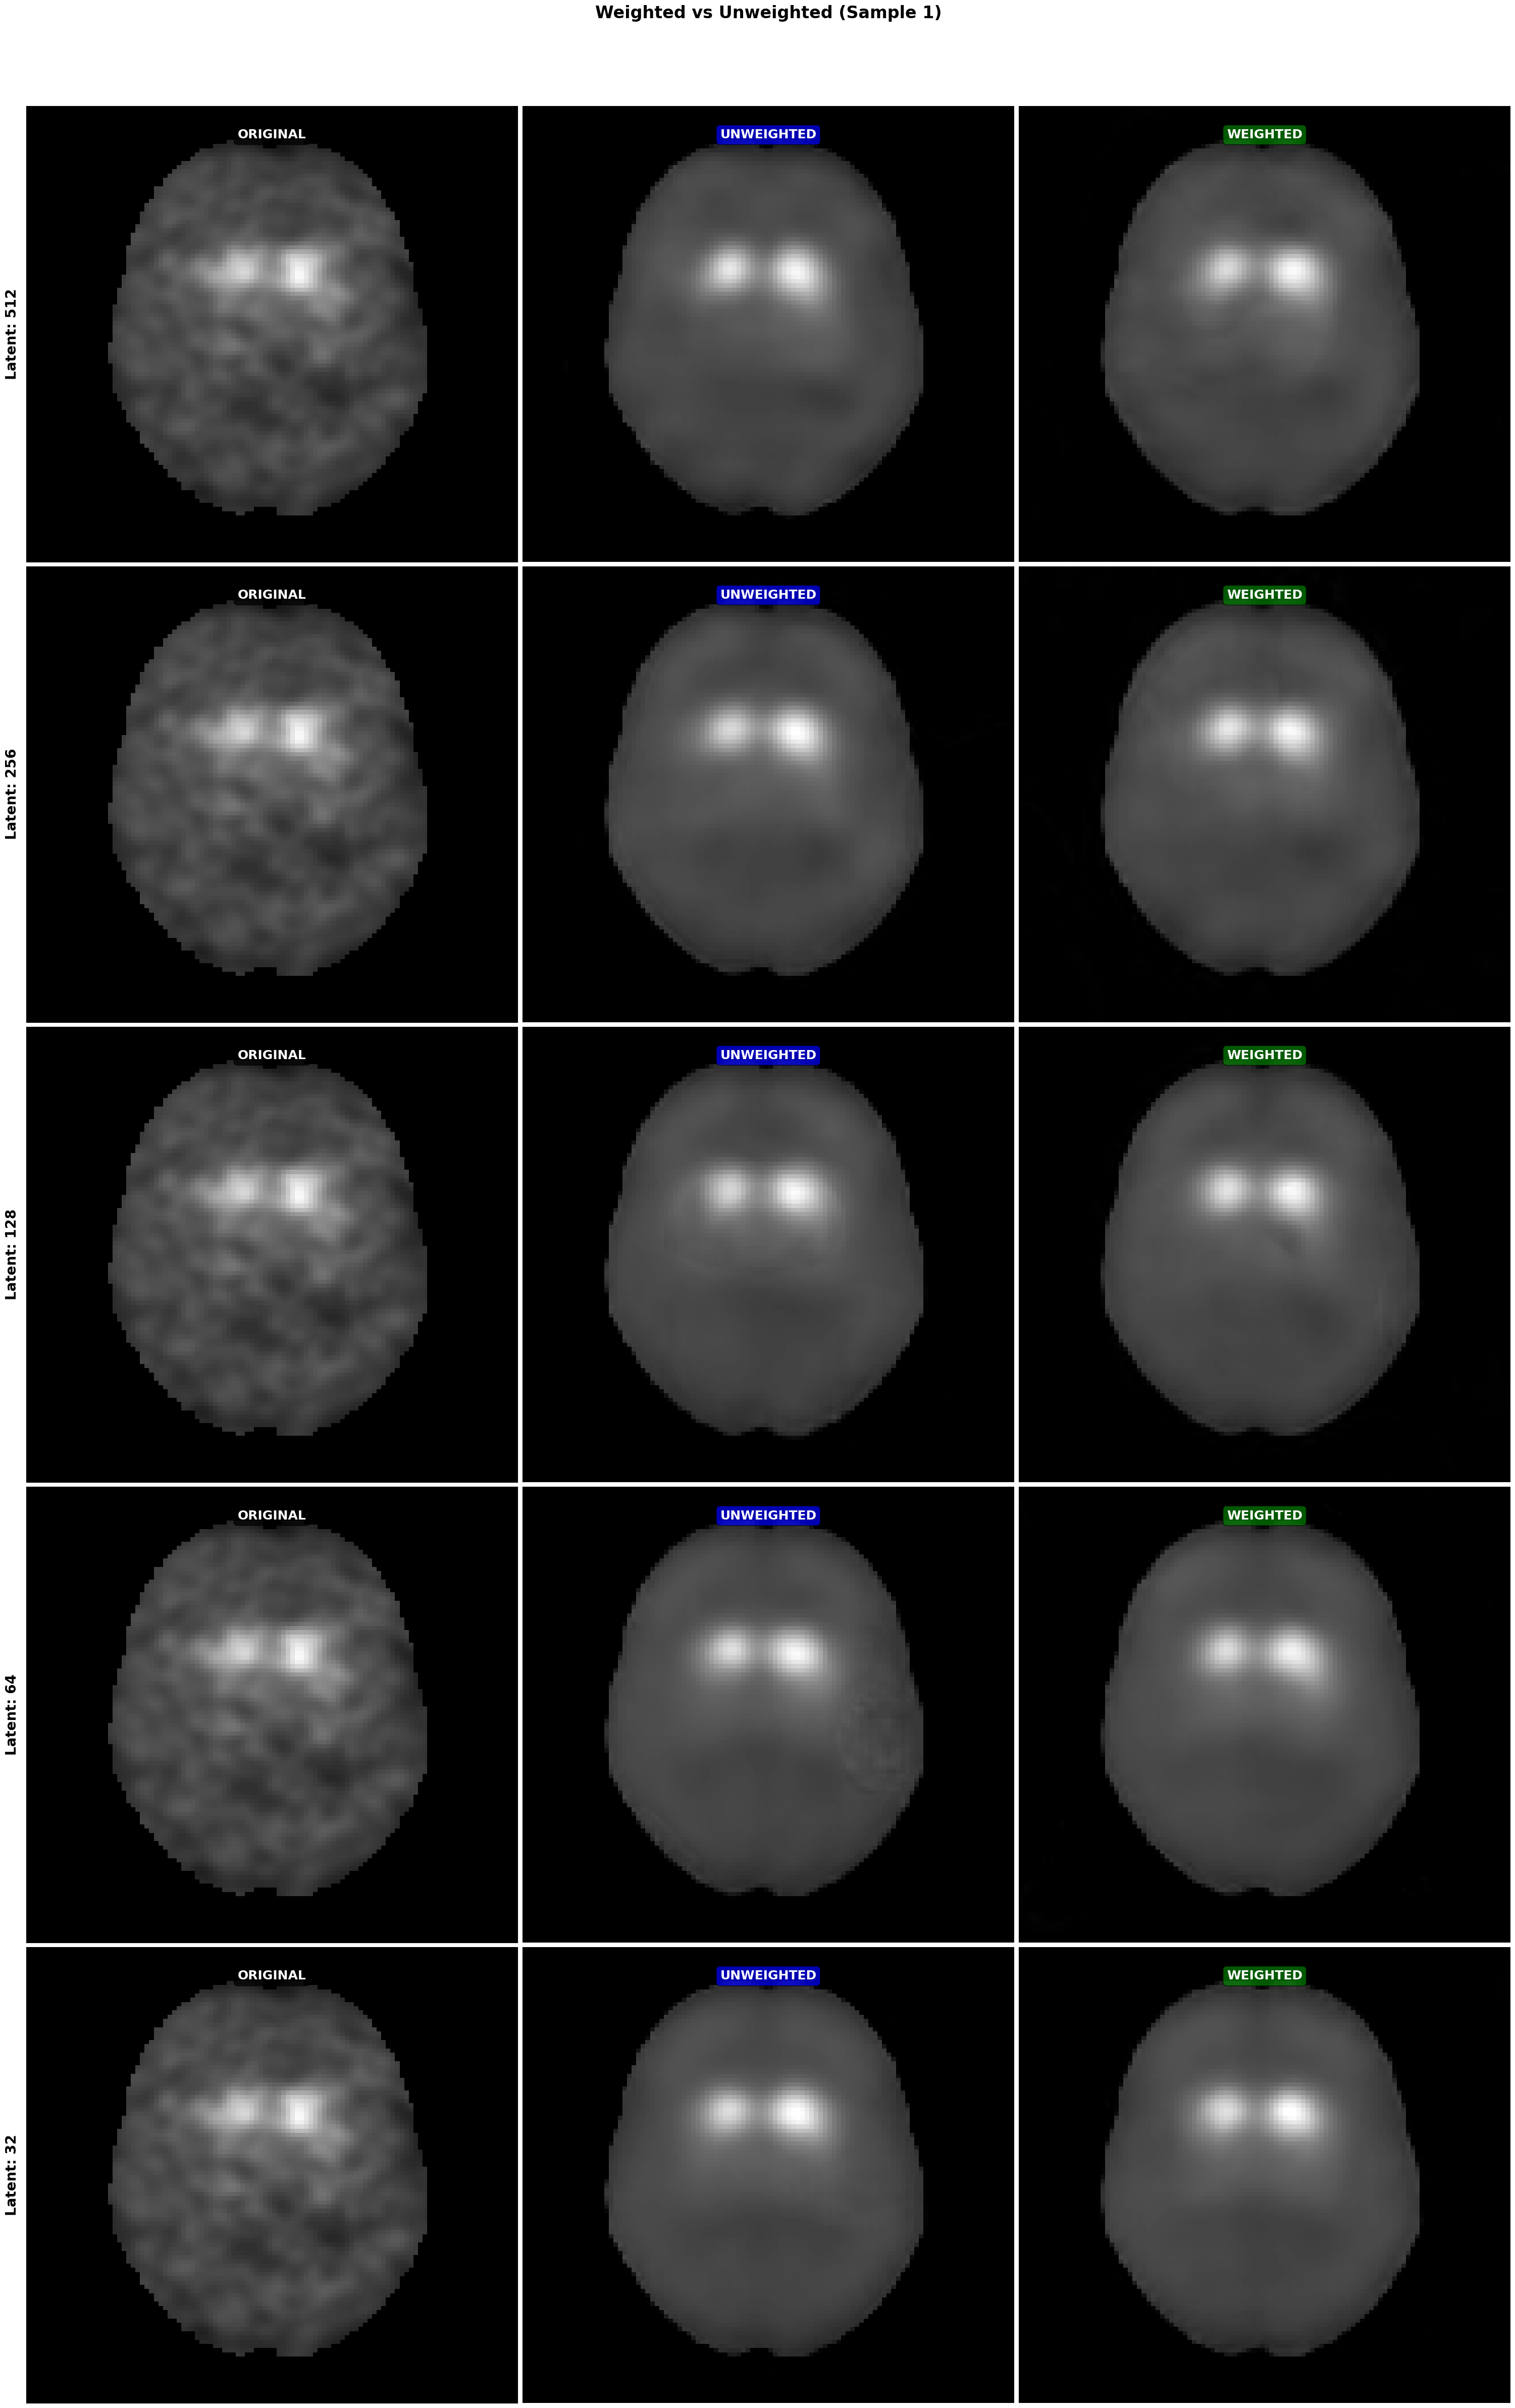

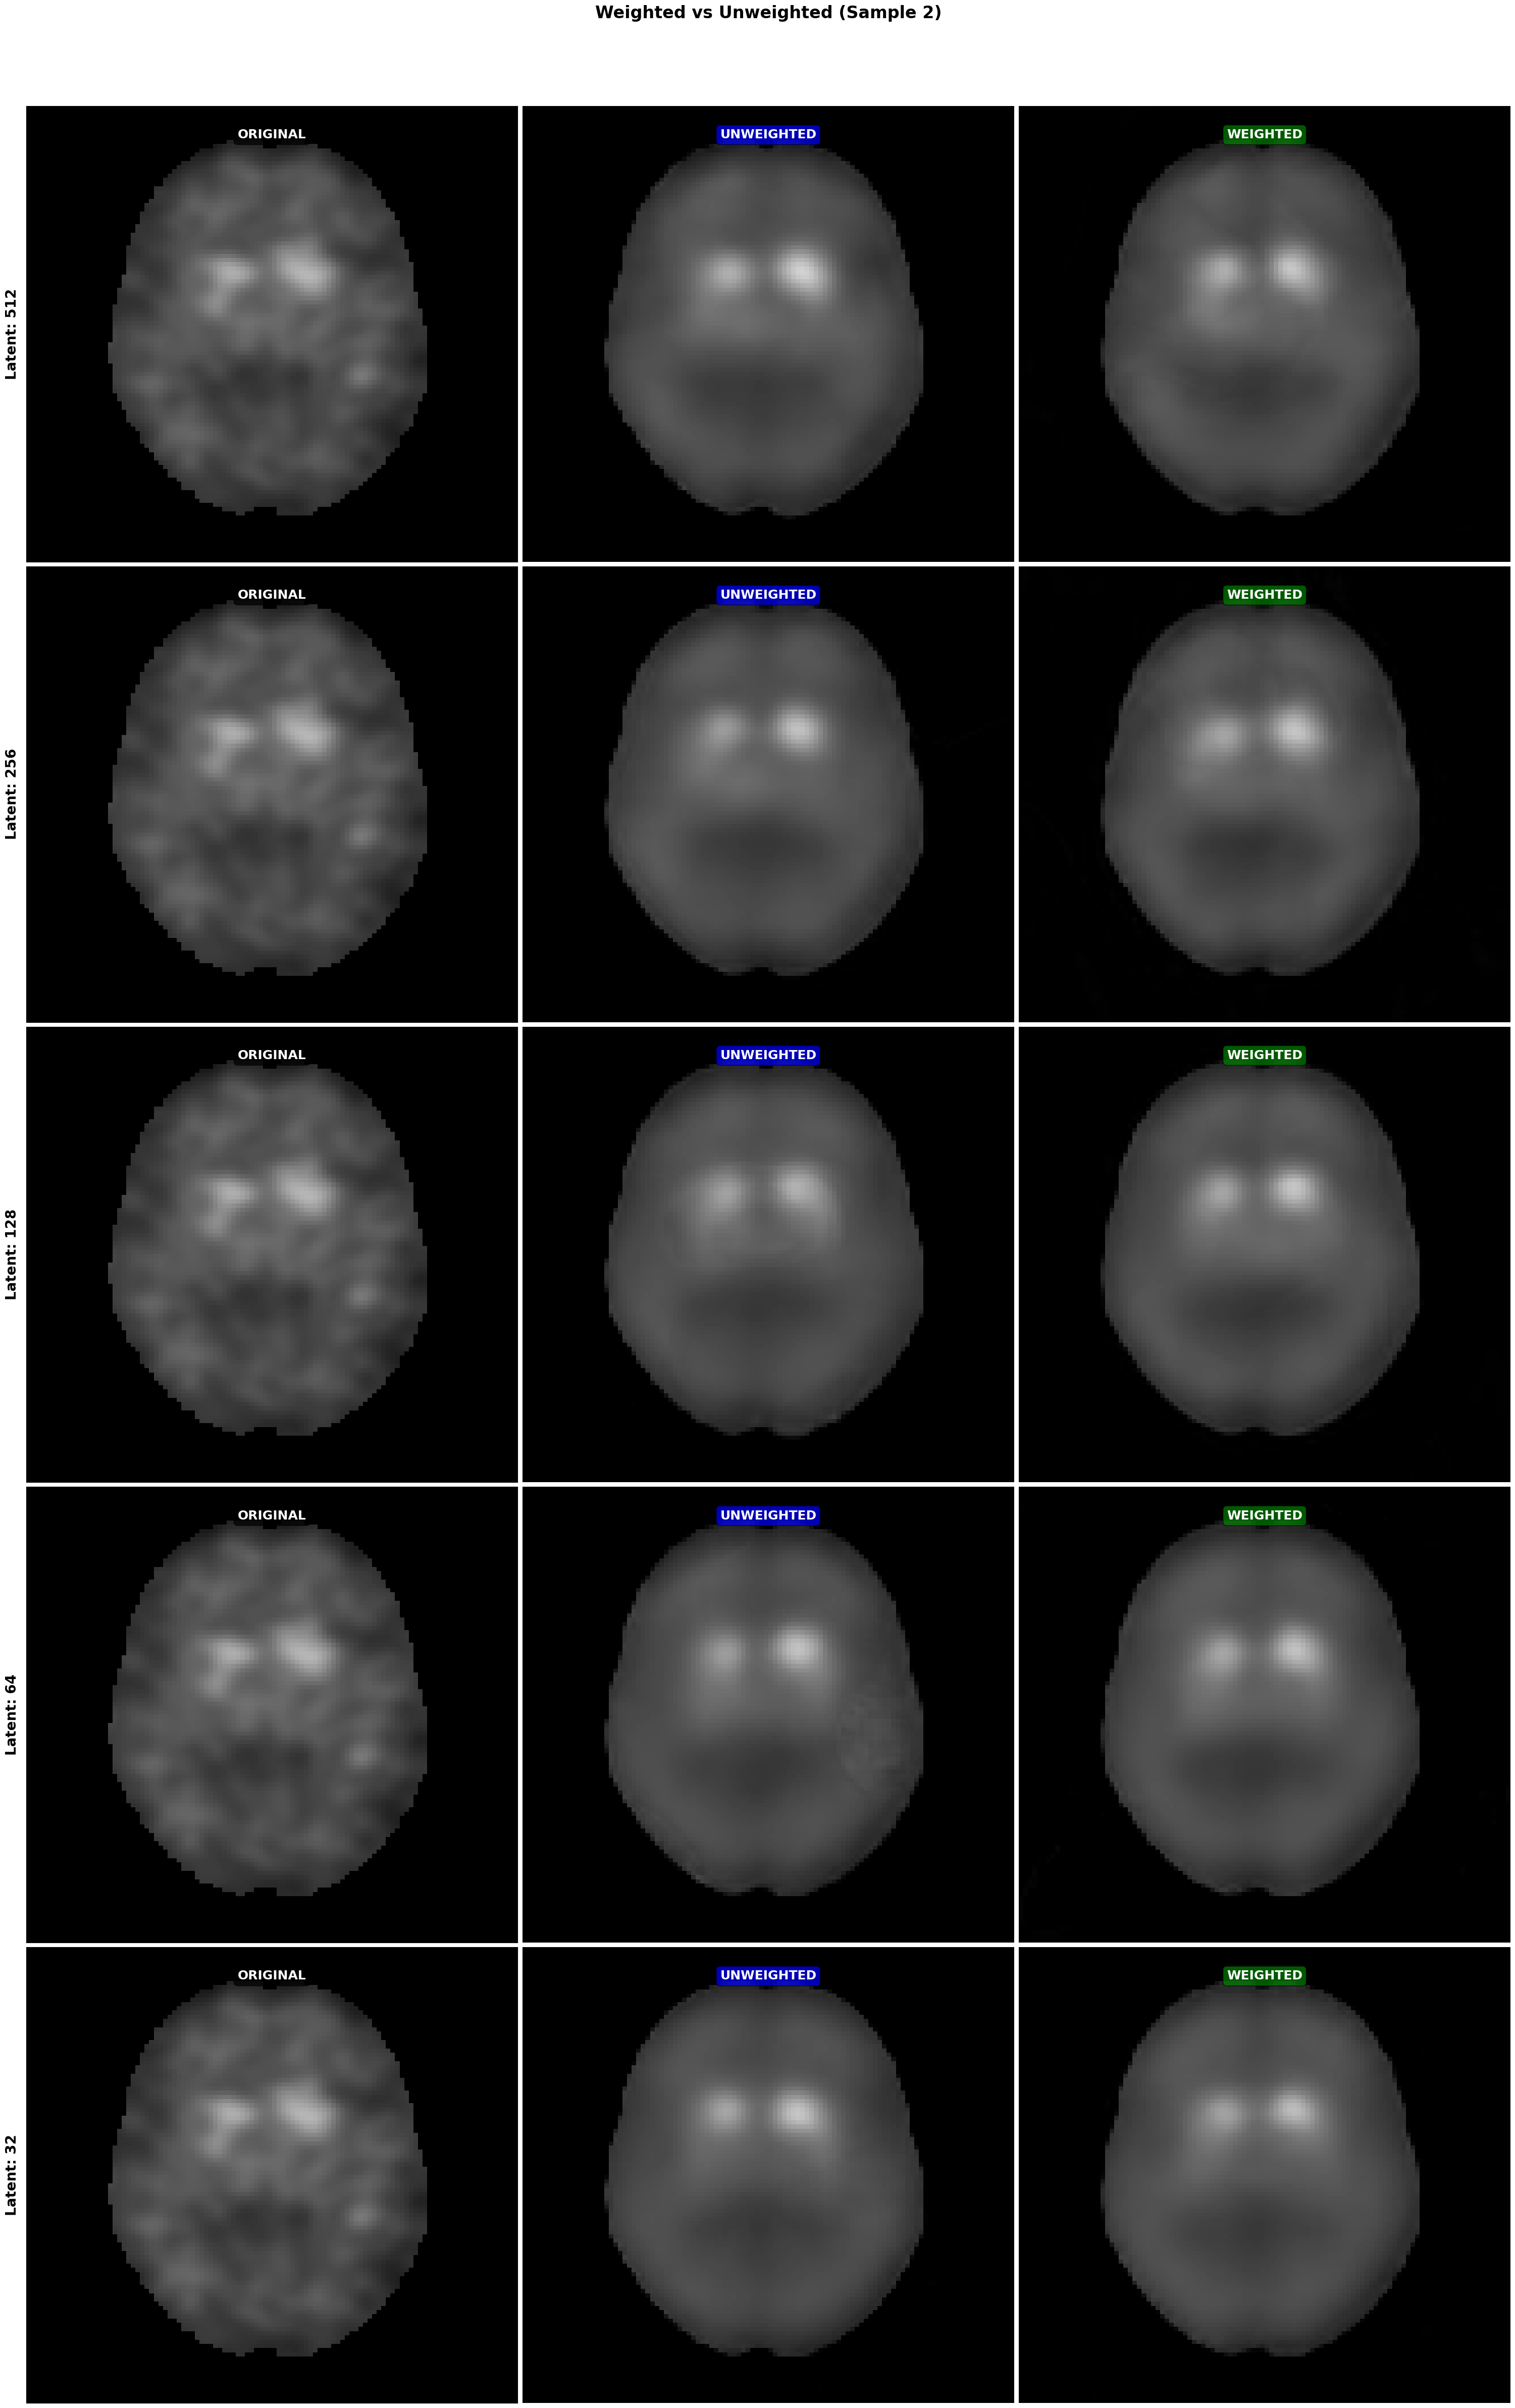

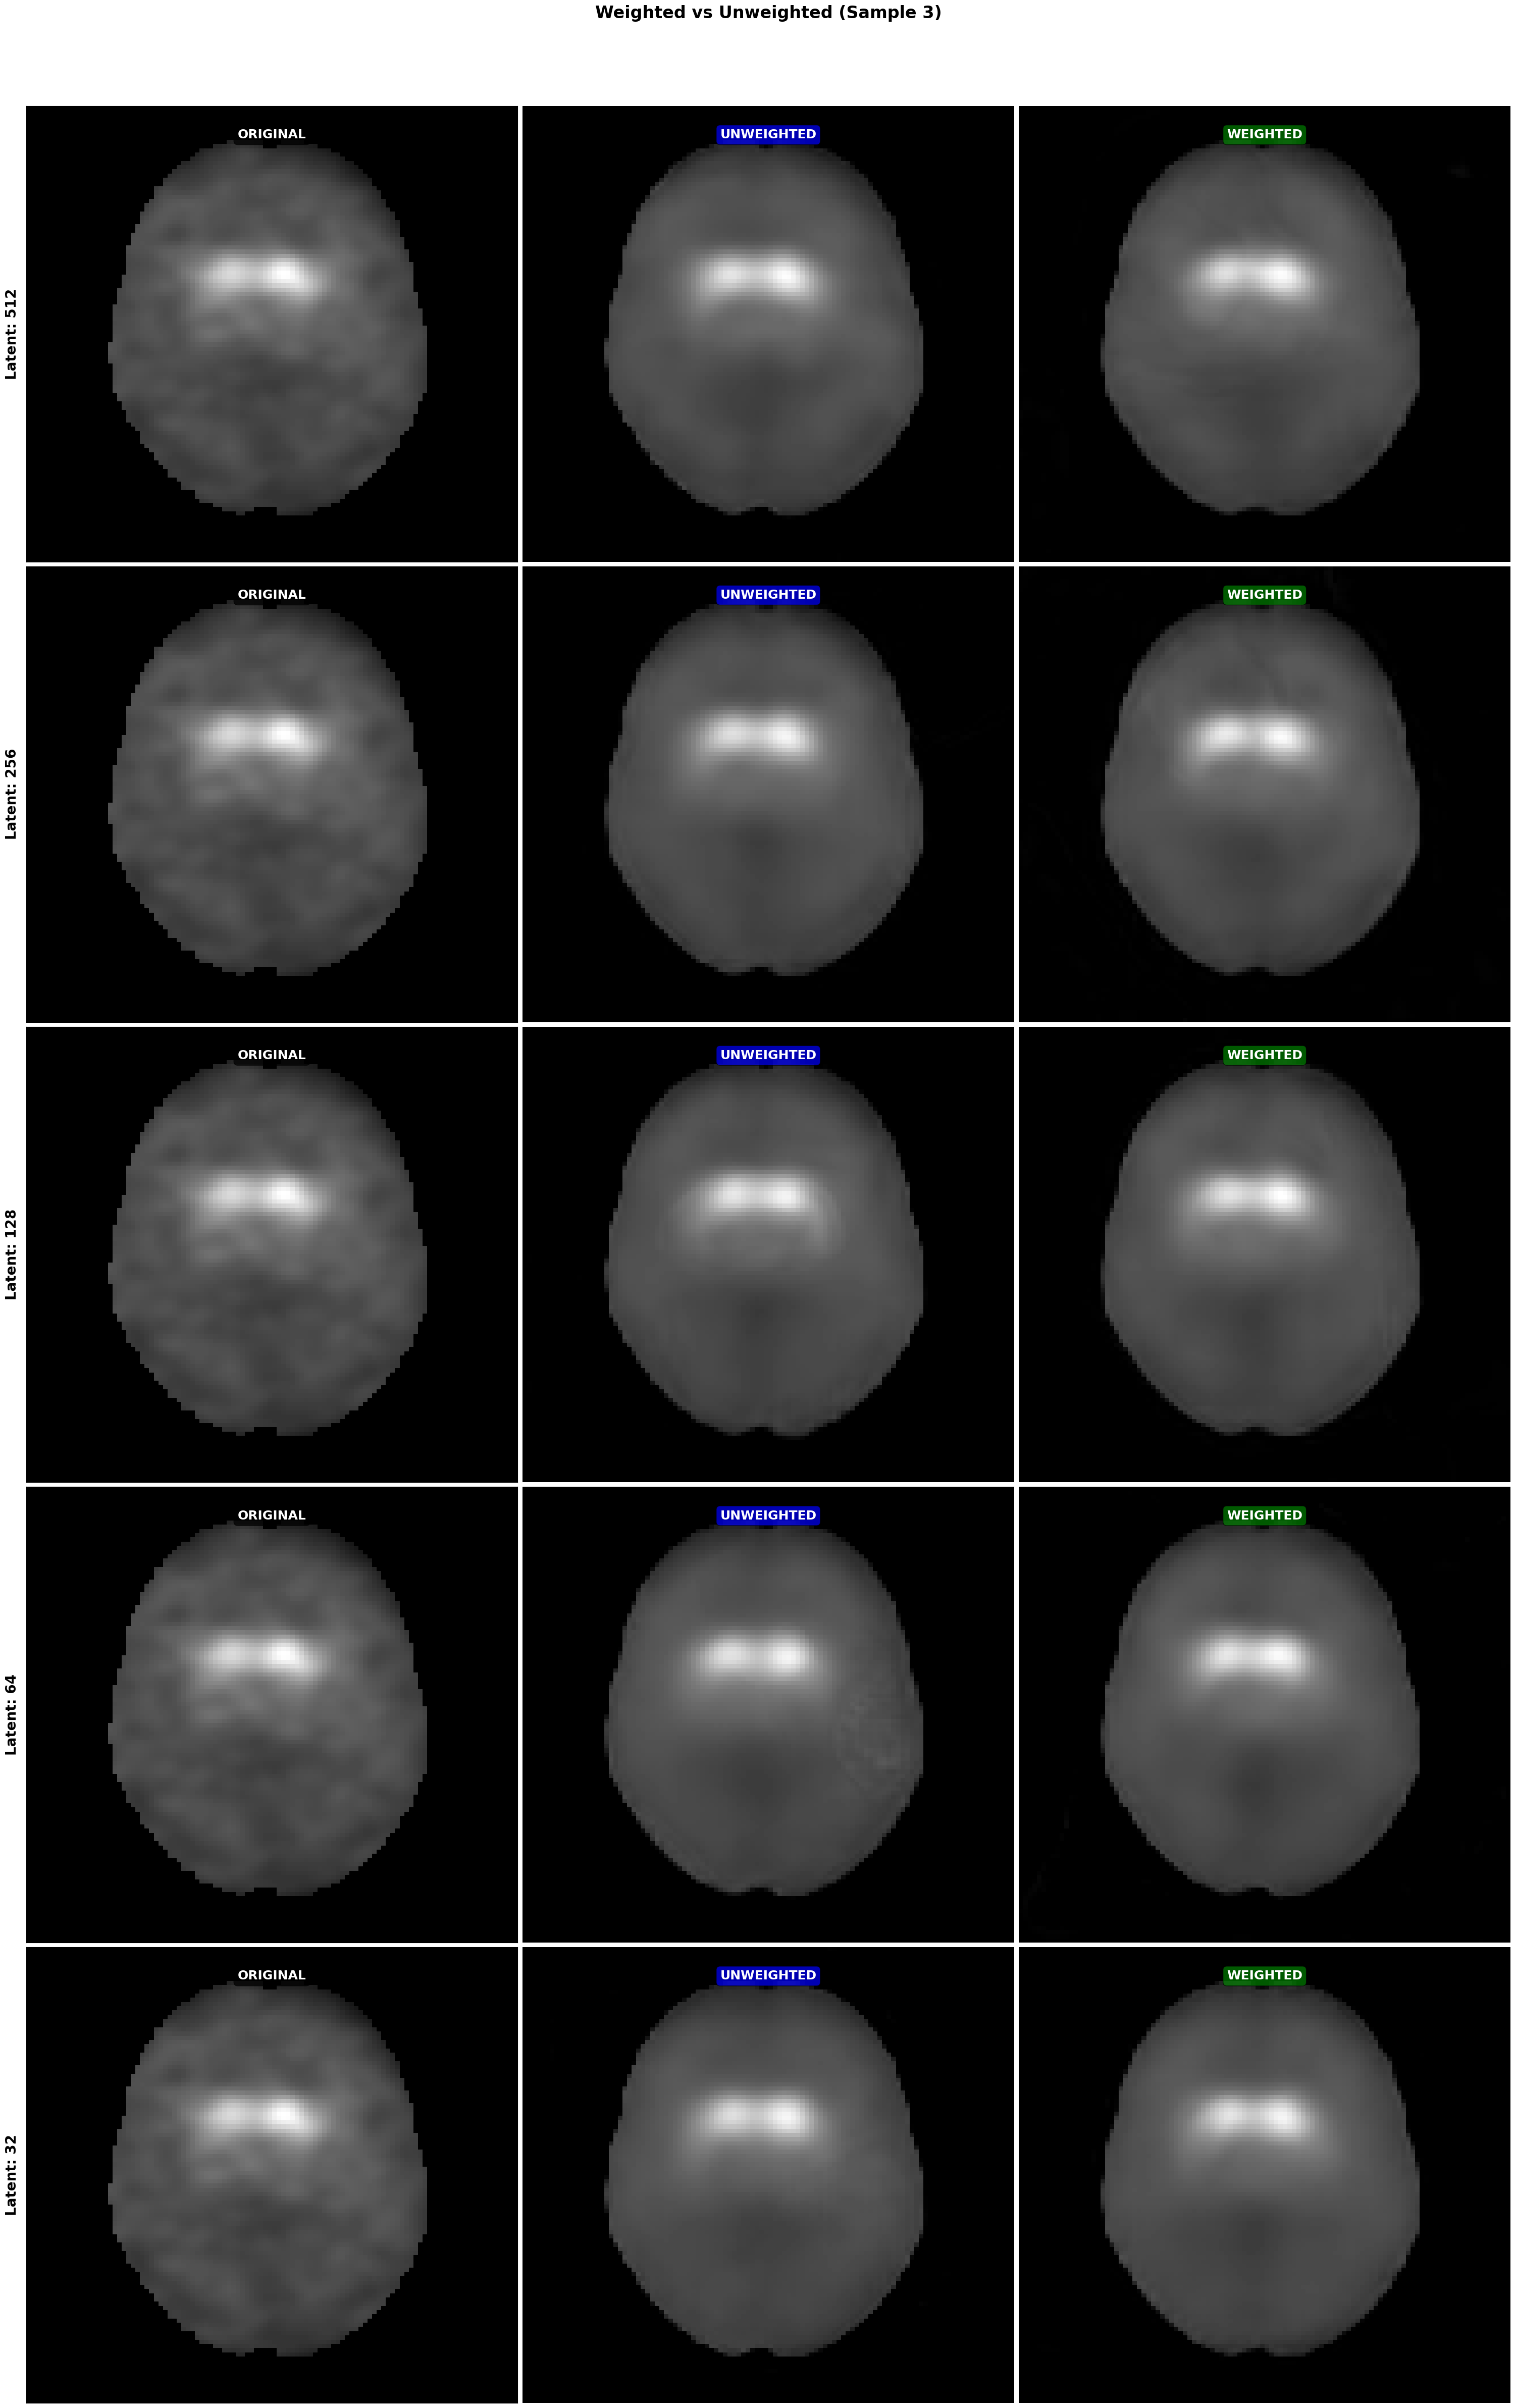

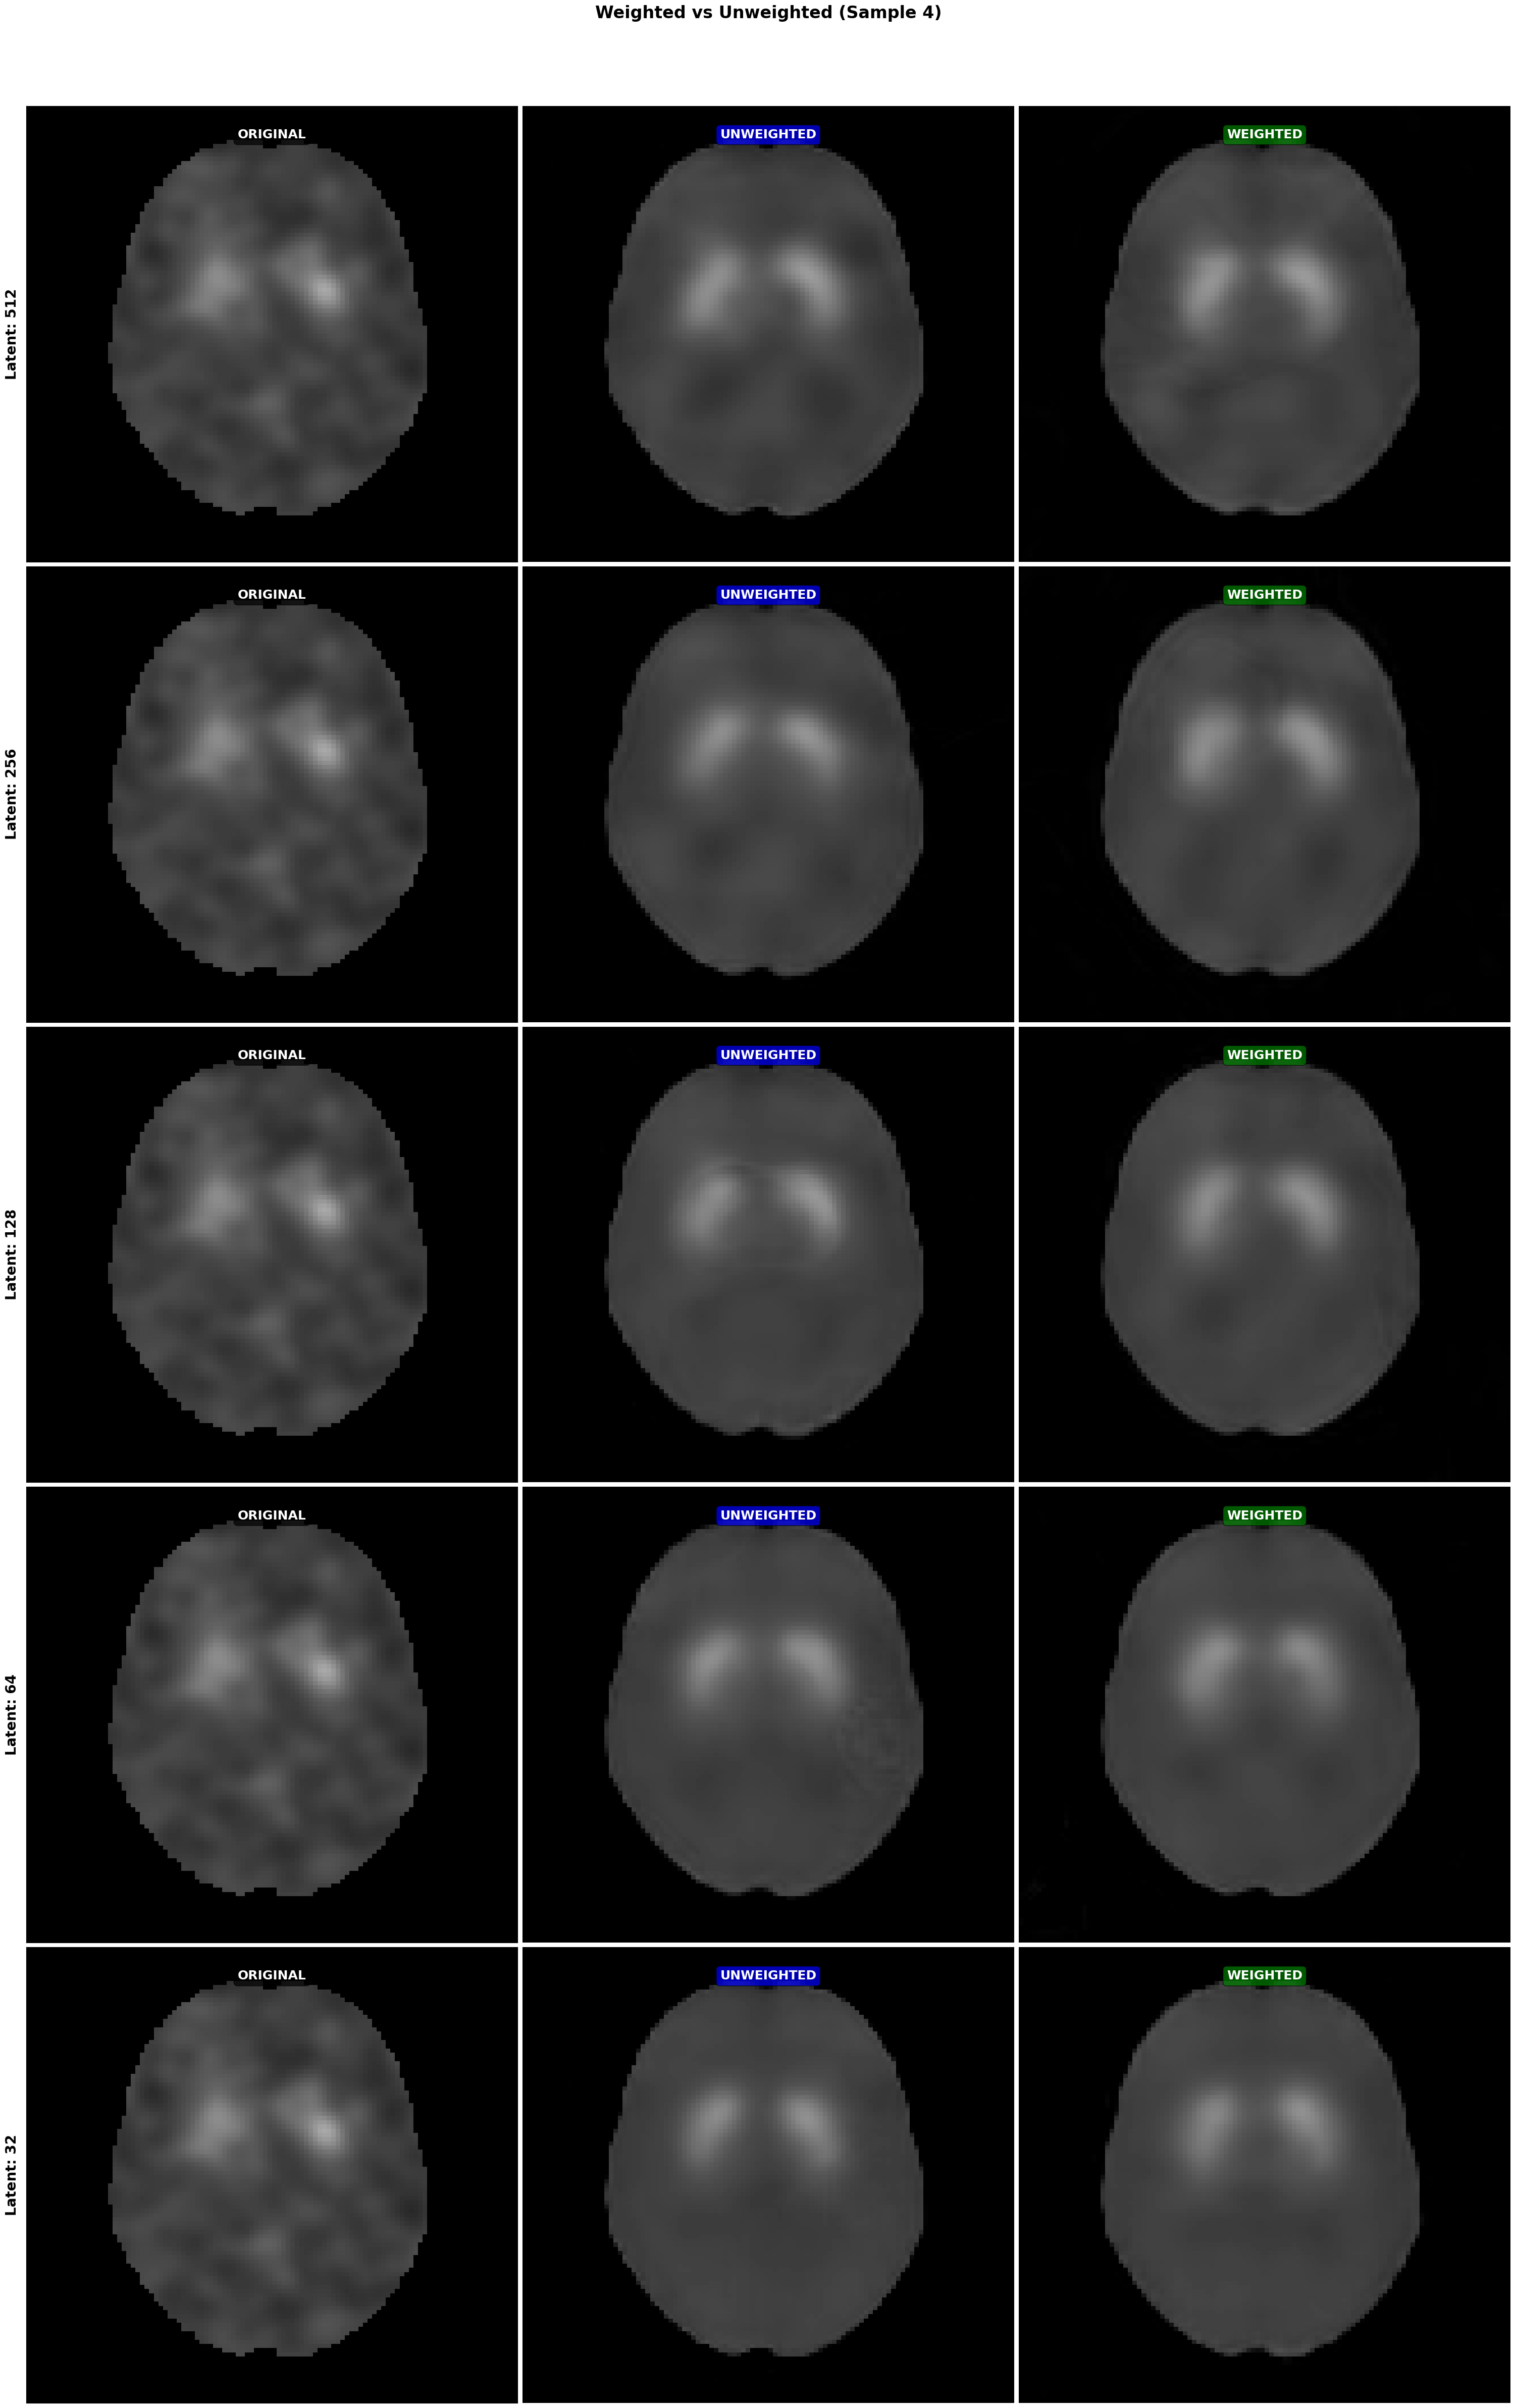

Axial comparison visualizations saved to output/Experiments/WeightedUnweightedComparison


In [18]:
# Visualize side-by-side comparisons for each sample in batch
for pIdx in range(min(4, inp.shape[0])):
    
    num_rows = len(deconv_latent_dims)
    num_cols = 3
    
    # 1. OPTIMIZE FIGURE SIZE
    # Instead of a fixed (32, 24), we calculate height based on the number of rows.
    # This prevents vertical white bars if you have few rows, or squishing if you have many.
    # We assume roughly square images. 
    fig_width = 30
    fig_height = (fig_width / num_cols) * num_rows
    
    fig = plt.figure(figsize=(fig_width, fig_height)) # Height scales dynamically
    
    # Loop through each latent dimension
    for col_idx, latent_dim in enumerate(deconv_latent_dims):
        unweighted_model_name = f"deconv_lat{latent_dim}"
        weighted_model_name = f"deconv_weighted_lat{latent_dim}"
        
        unweighted_recon = unweighted_reconstructions[unweighted_model_name]
        weighted_recon = weighted_reconstructions[weighted_model_name]
        
        # --- Original image ---
        ax = plt.subplot(num_rows, num_cols, col_idx * 3 + 1)
        ax.imshow(inp[pIdx, 0, 32, 10:-10, 10:-10].cpu(), cmap='gray', vmin=-0., vmax=4., aspect='auto')
        
        # Title only on the first column to save vertical space
        ax.set_ylabel(f"Latent: {latent_dim}", fontsize=20, fontweight='bold', labelpad=10)
        
        ax.text(0.5, 0.95, "ORIGINAL", transform=ax.transAxes, fontsize=18, fontweight='bold',
               ha='center', va='top', color='white', bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
        
        # Remove axes ticks but keep the box for structure (optional, can use axis('off'))
        ax.set_xticks([])
        ax.set_yticks([])
        
        # --- Unweighted reconstruction ---
        ax = plt.subplot(num_rows, num_cols, col_idx * 3 + 2)
        ax.imshow(unweighted_recon[pIdx, 0, 32, 10:-10, 10:-10].cpu(), cmap='gray', vmin=-0., vmax=4., aspect='auto')

        ax.text(0.5, 0.95, "UNWEIGHTED", transform=ax.transAxes, fontsize=18, fontweight='bold',
               ha='center', va='top', color='white', bbox=dict(boxstyle='round', facecolor='blue', alpha=0.7))
        ax.axis('off')
        
        # --- Weighted reconstruction ---
        ax = plt.subplot(num_rows, num_cols, col_idx * 3 + 3)
        ax.imshow(weighted_recon[pIdx, 0, 32, 10:-10, 10:-10].cpu(), cmap='gray', vmin=-0., vmax=4., aspect='auto')

        ax.text(0.5, 0.95, "WEIGHTED", transform=ax.transAxes, fontsize=18, fontweight='bold',
               ha='center', va='top', color='white', bbox=dict(boxstyle='round', facecolor='green', alpha=0.7))
        ax.axis('off')
    
    # 2. REMOVE WHITE SPACE (The most important part)
    # wspace/hspace: space between images (set to near zero)
    # left/right/top/bottom: margins around the edge of the figure
    plt.subplots_adjust(wspace=0.01, hspace=0.01, left=0.01, right=0.99, bottom=0.01, top=0.92)

    plt.suptitle(f"Weighted vs Unweighted (Sample {pIdx + 1})", 
                 fontsize=24, fontweight='bold', y=0.96) # Adjusted Y to fit tighter top margin
    
    # Note: tight_layout() is REMOVED because it often overrides subplots_adjust
    
    plt.savefig(os.path.join(comparison_output_dir, f"comparison_axial_sample_{pIdx+1}.png"), dpi=150, bbox_inches='tight')
    plt.show()

print(f"Axial comparison visualizations saved to {comparison_output_dir}")

## Side-by-Side Comparison - Coronal Slices

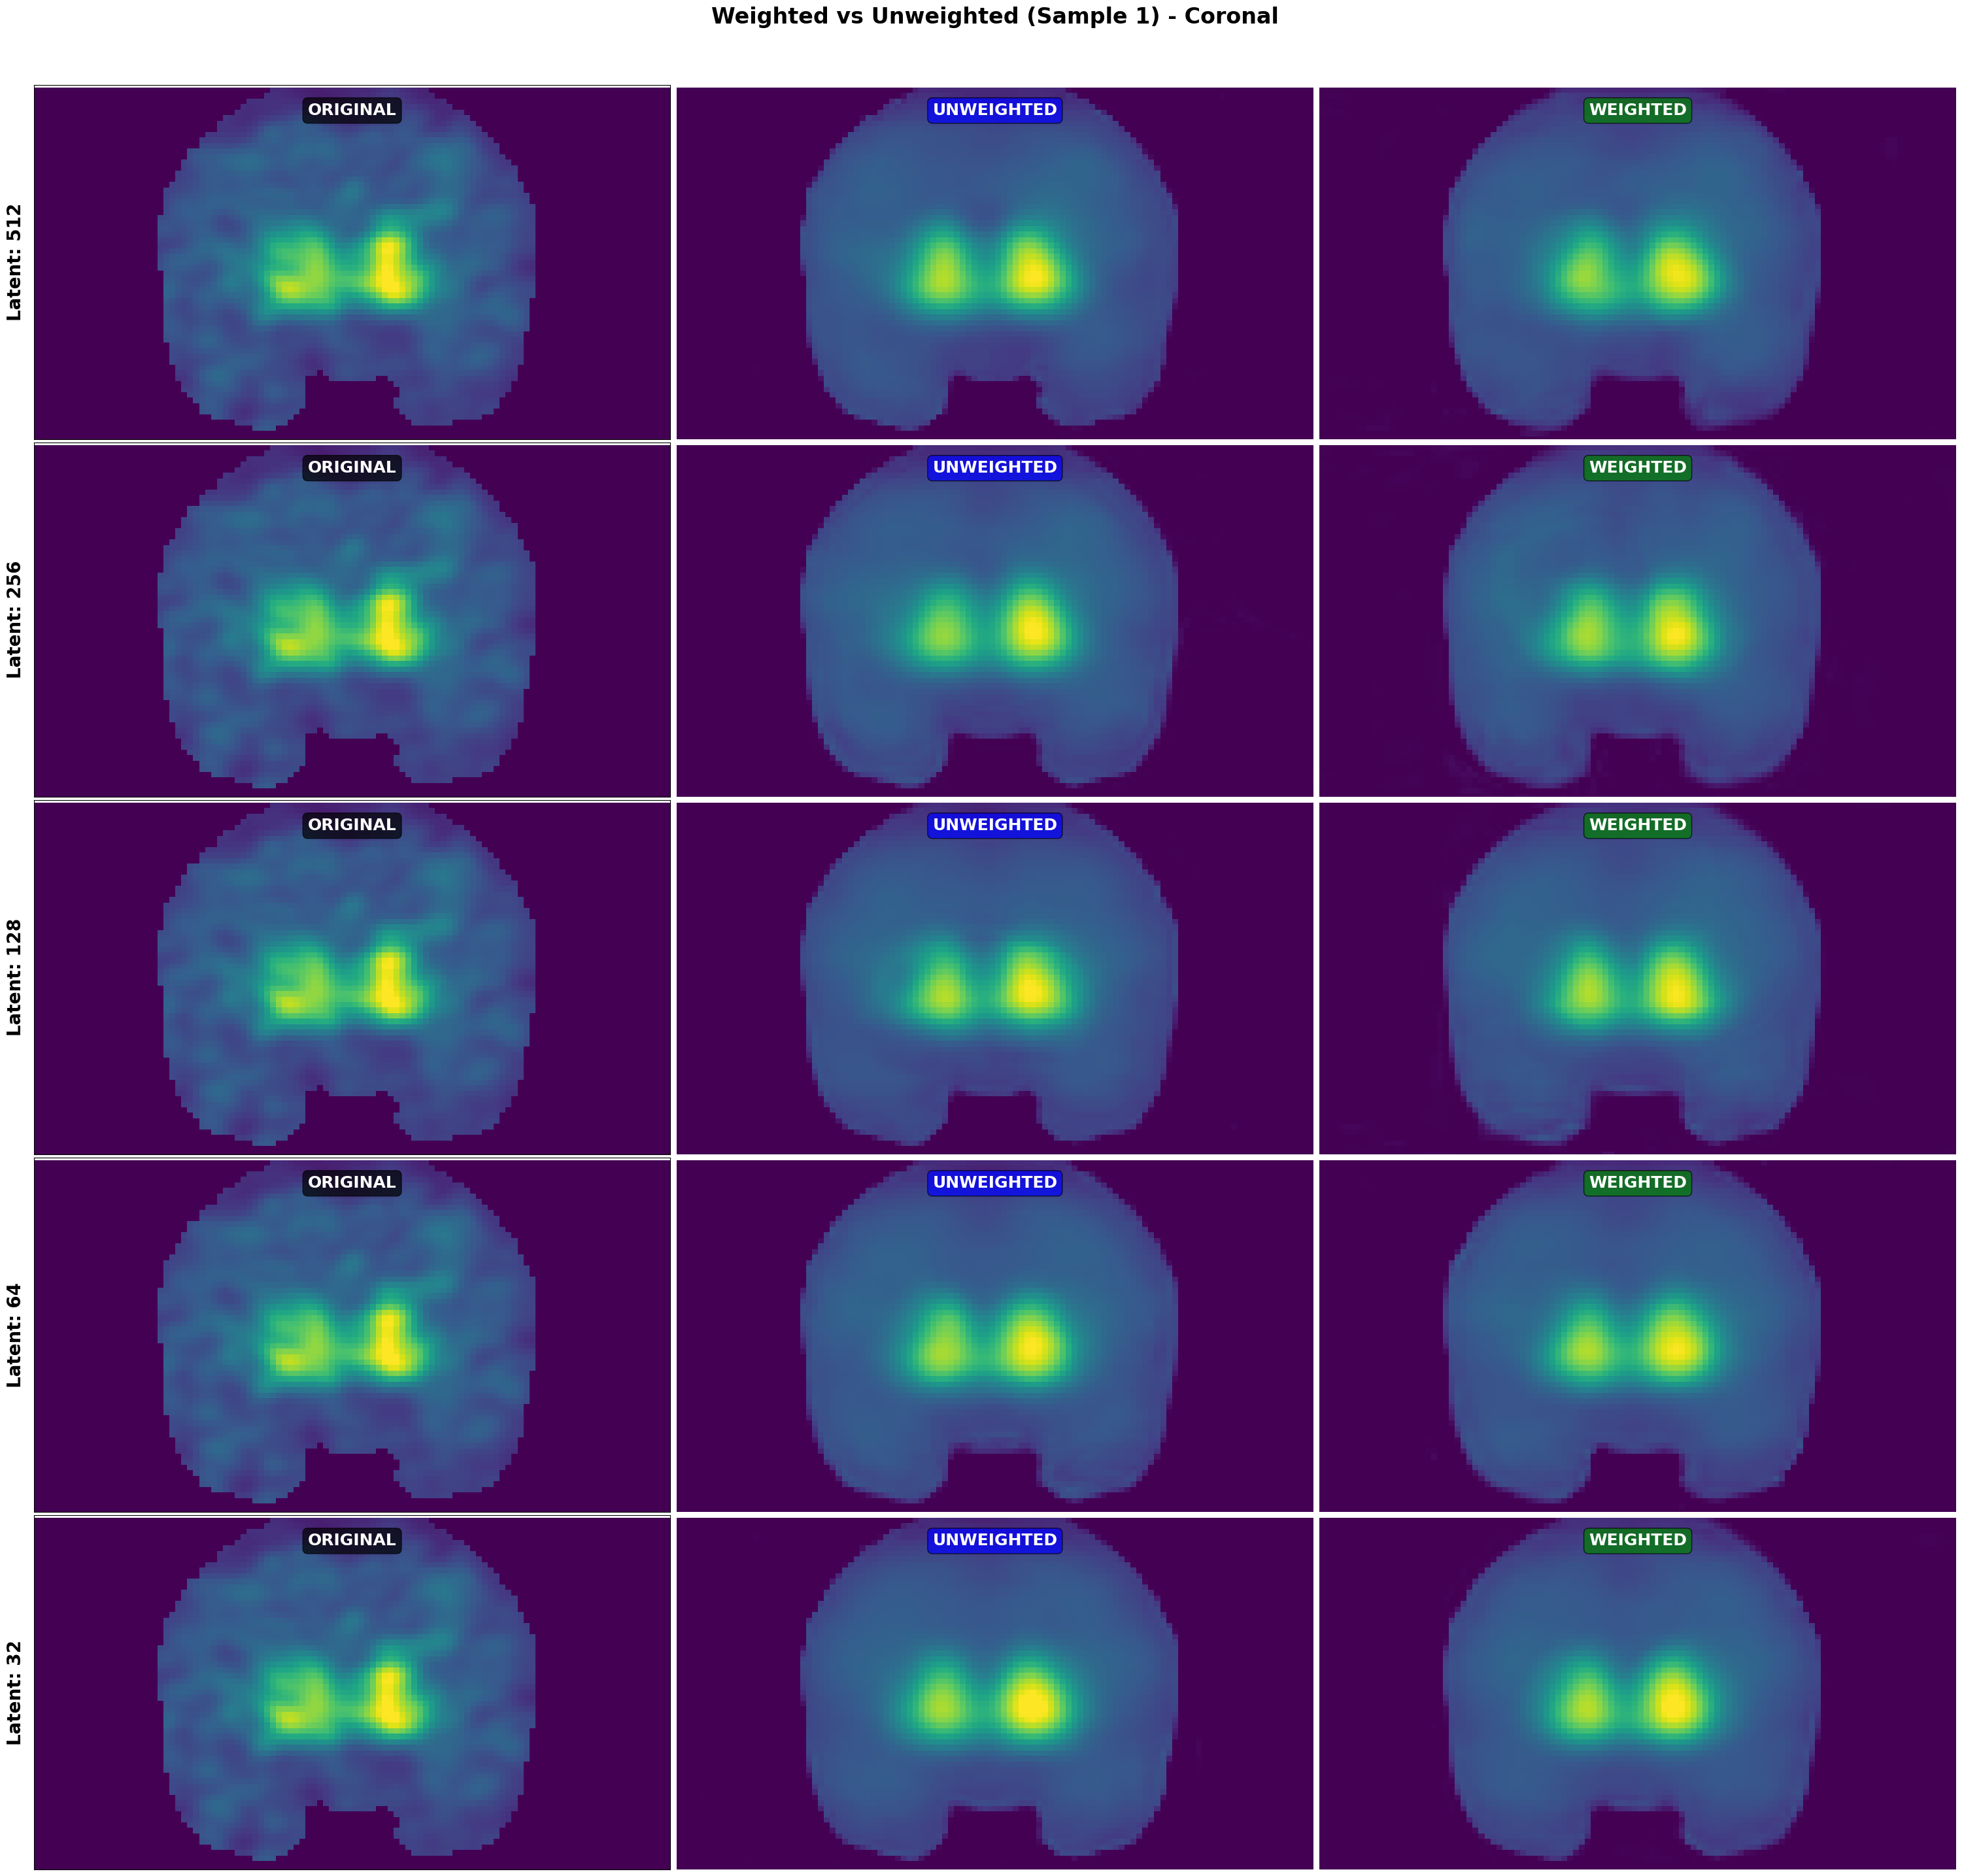

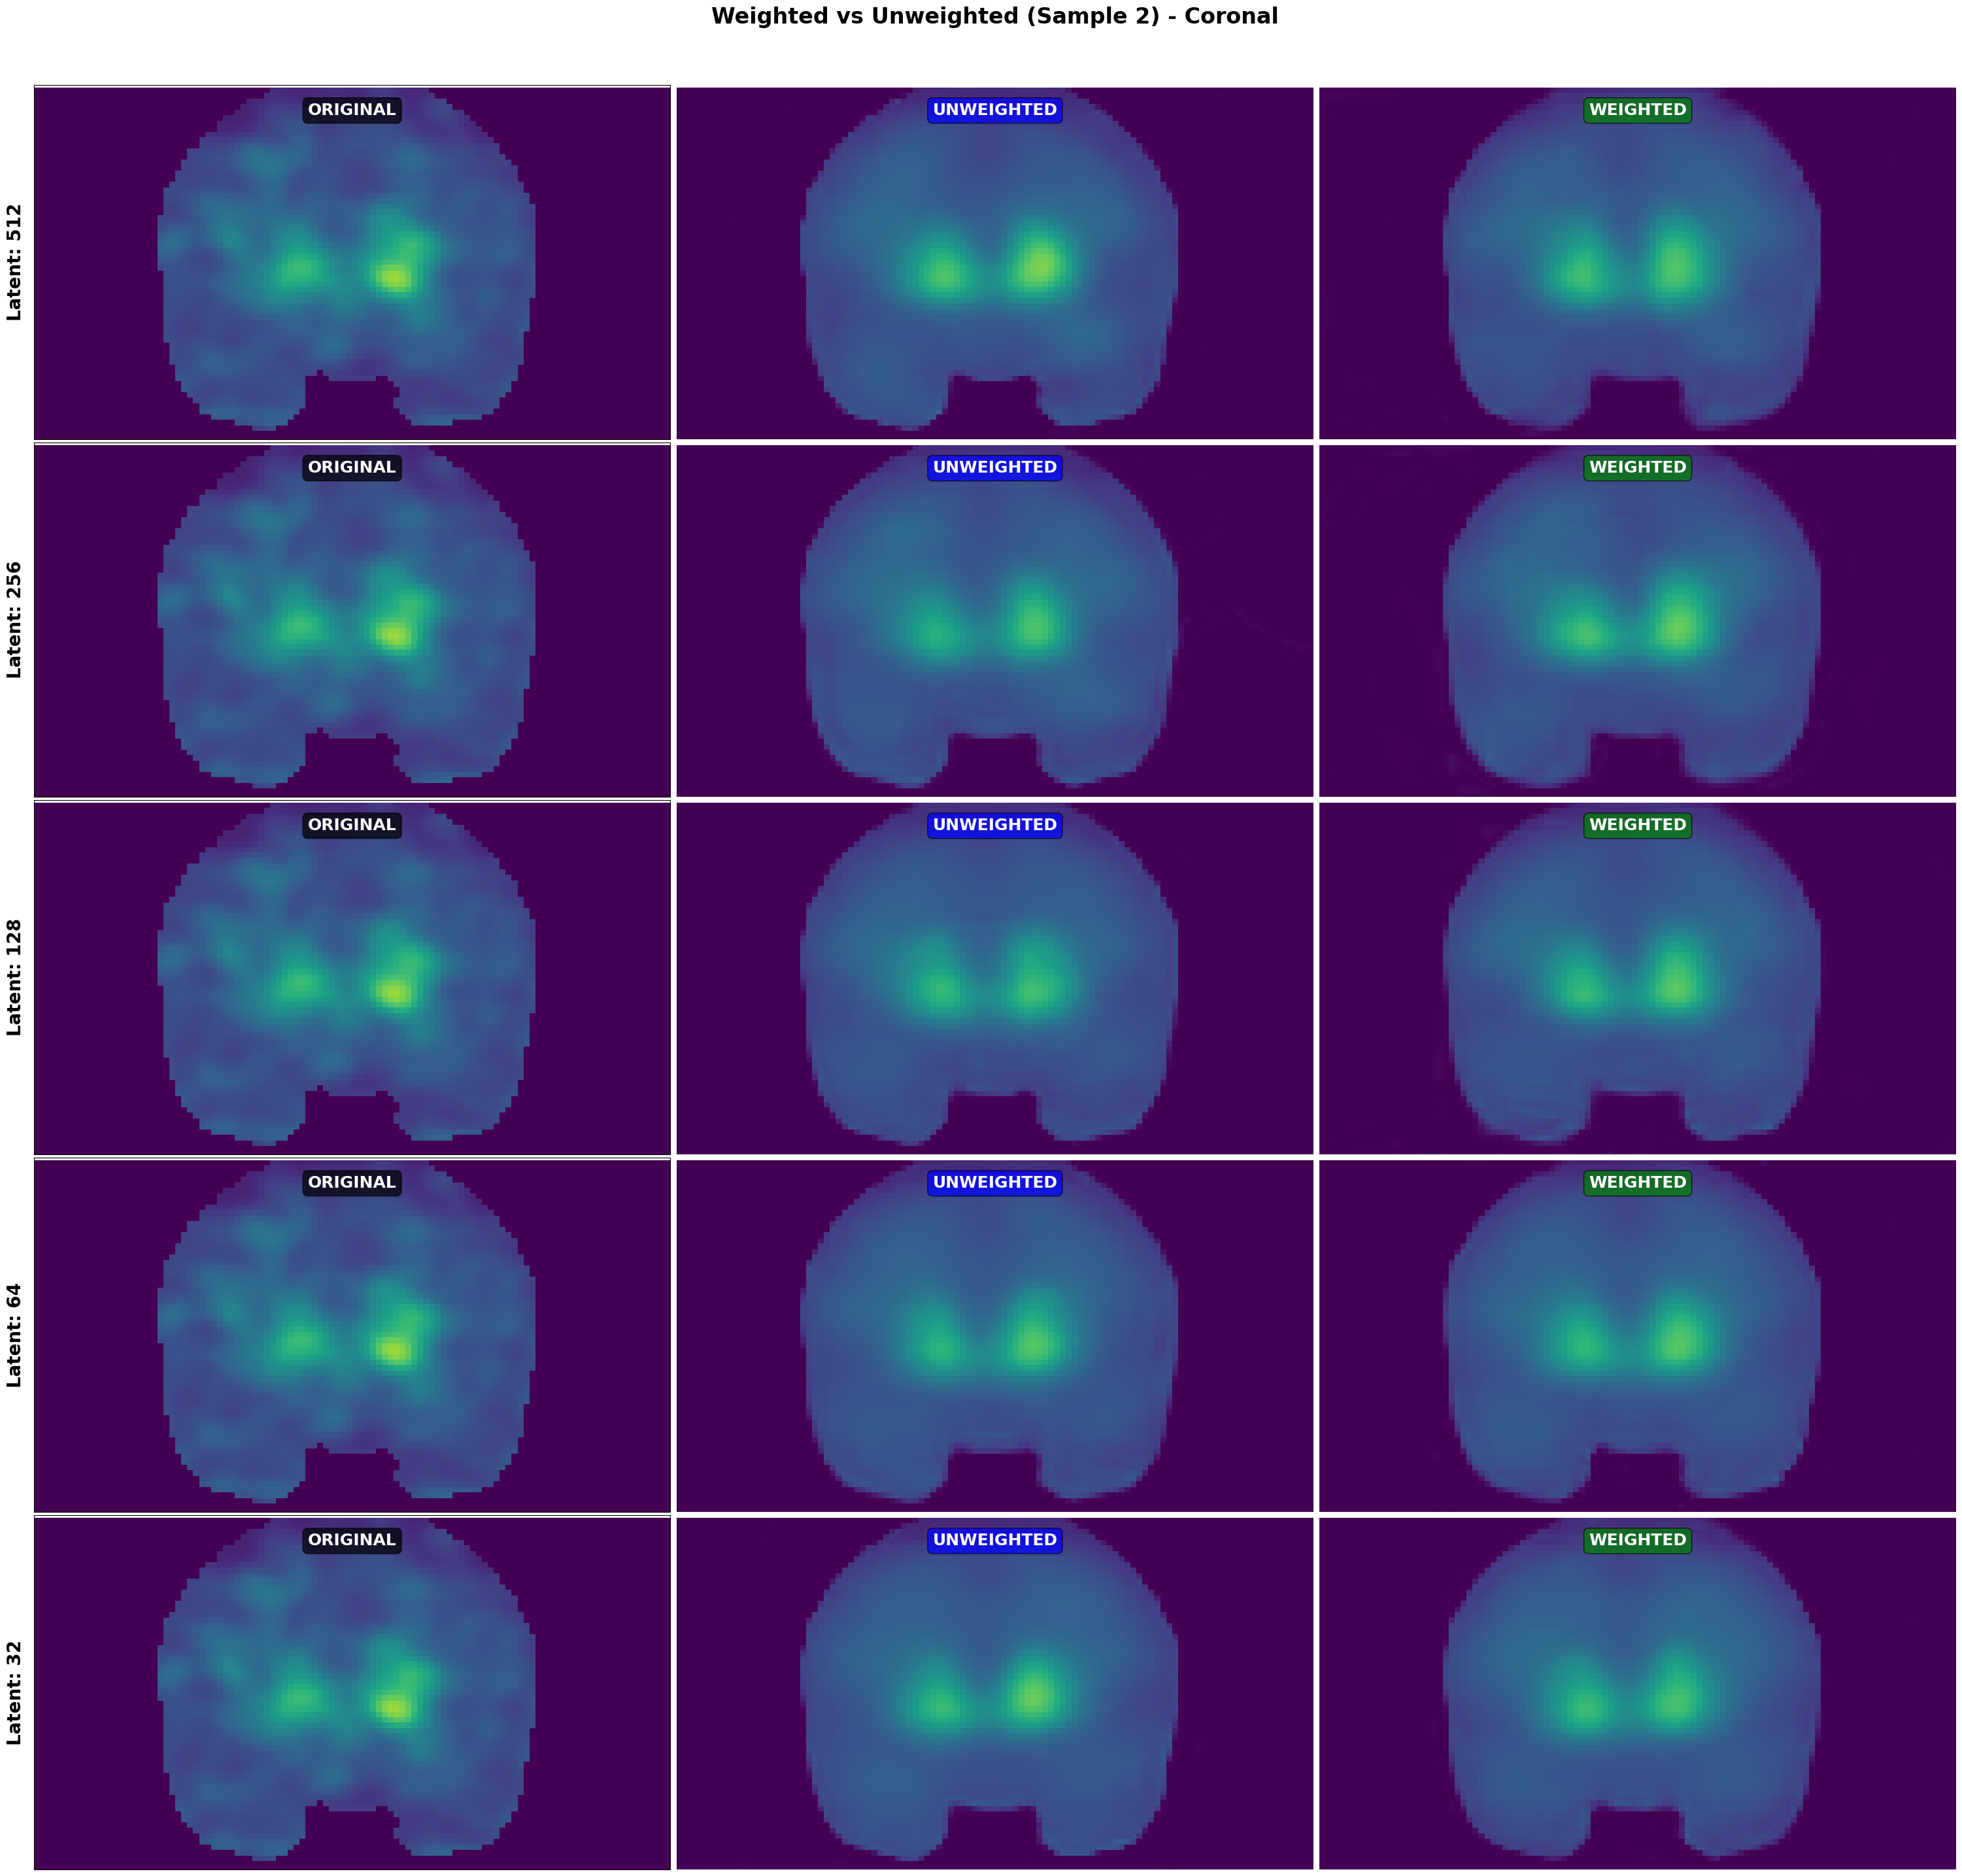

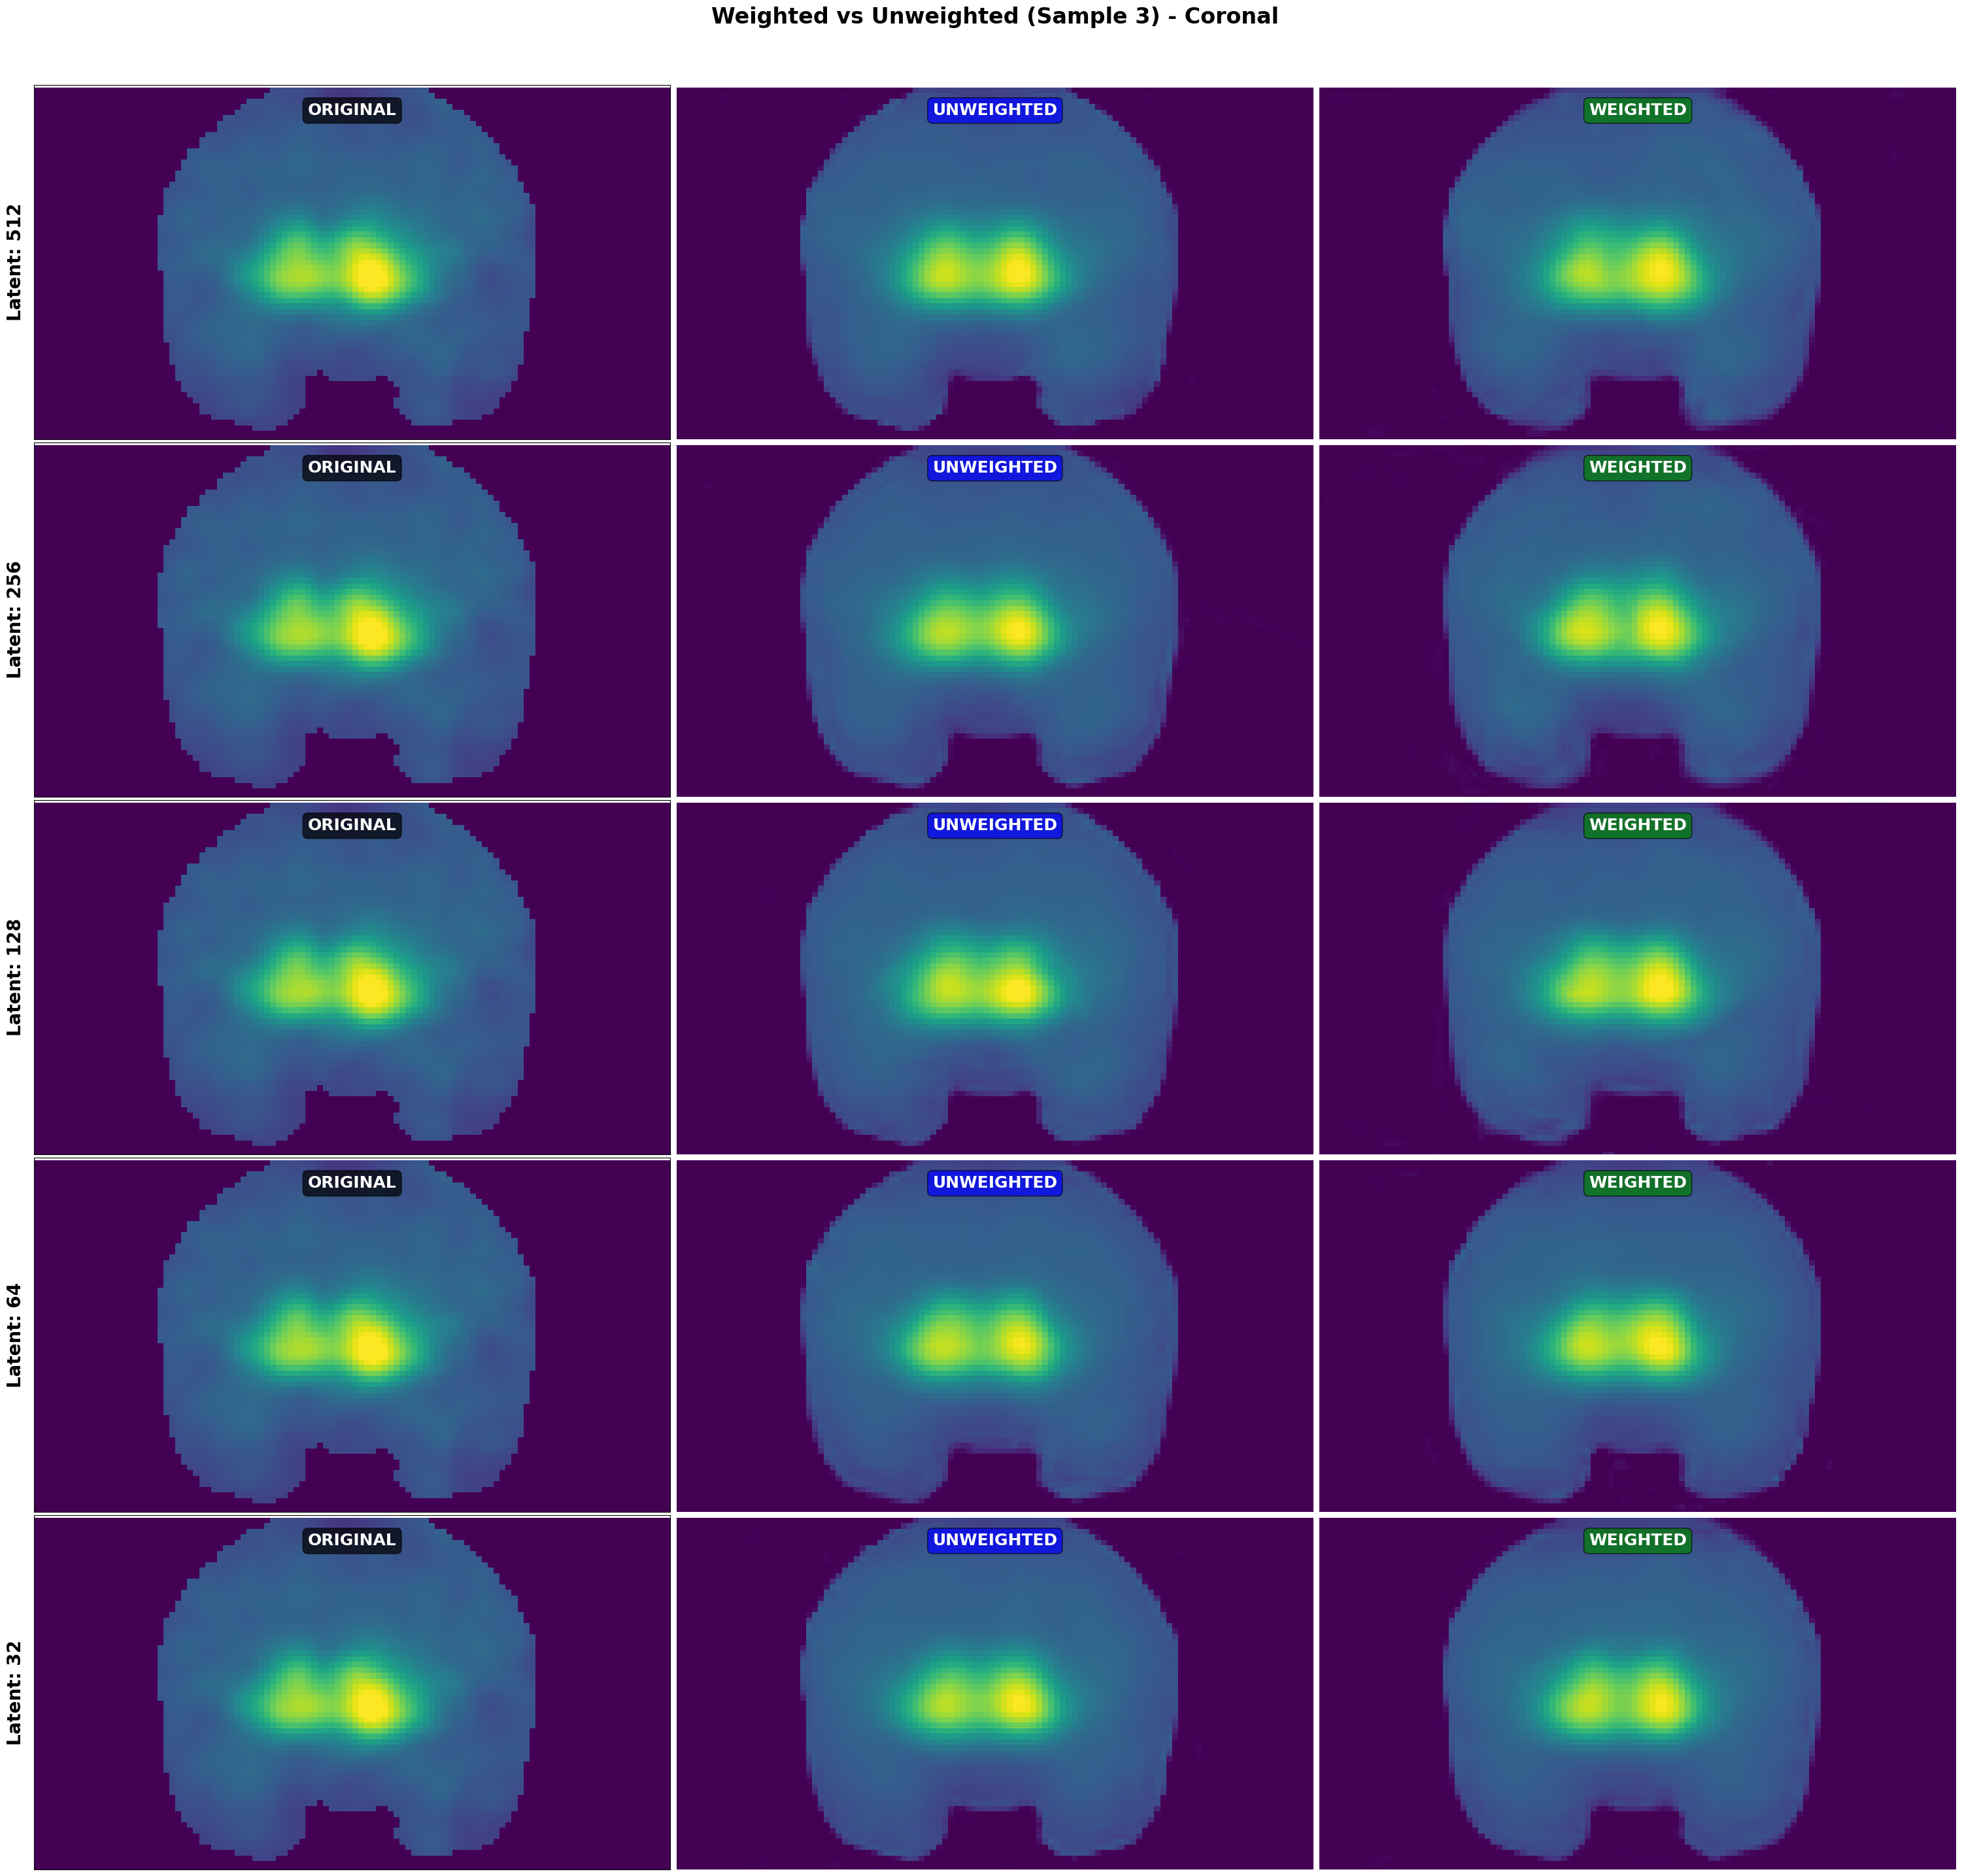

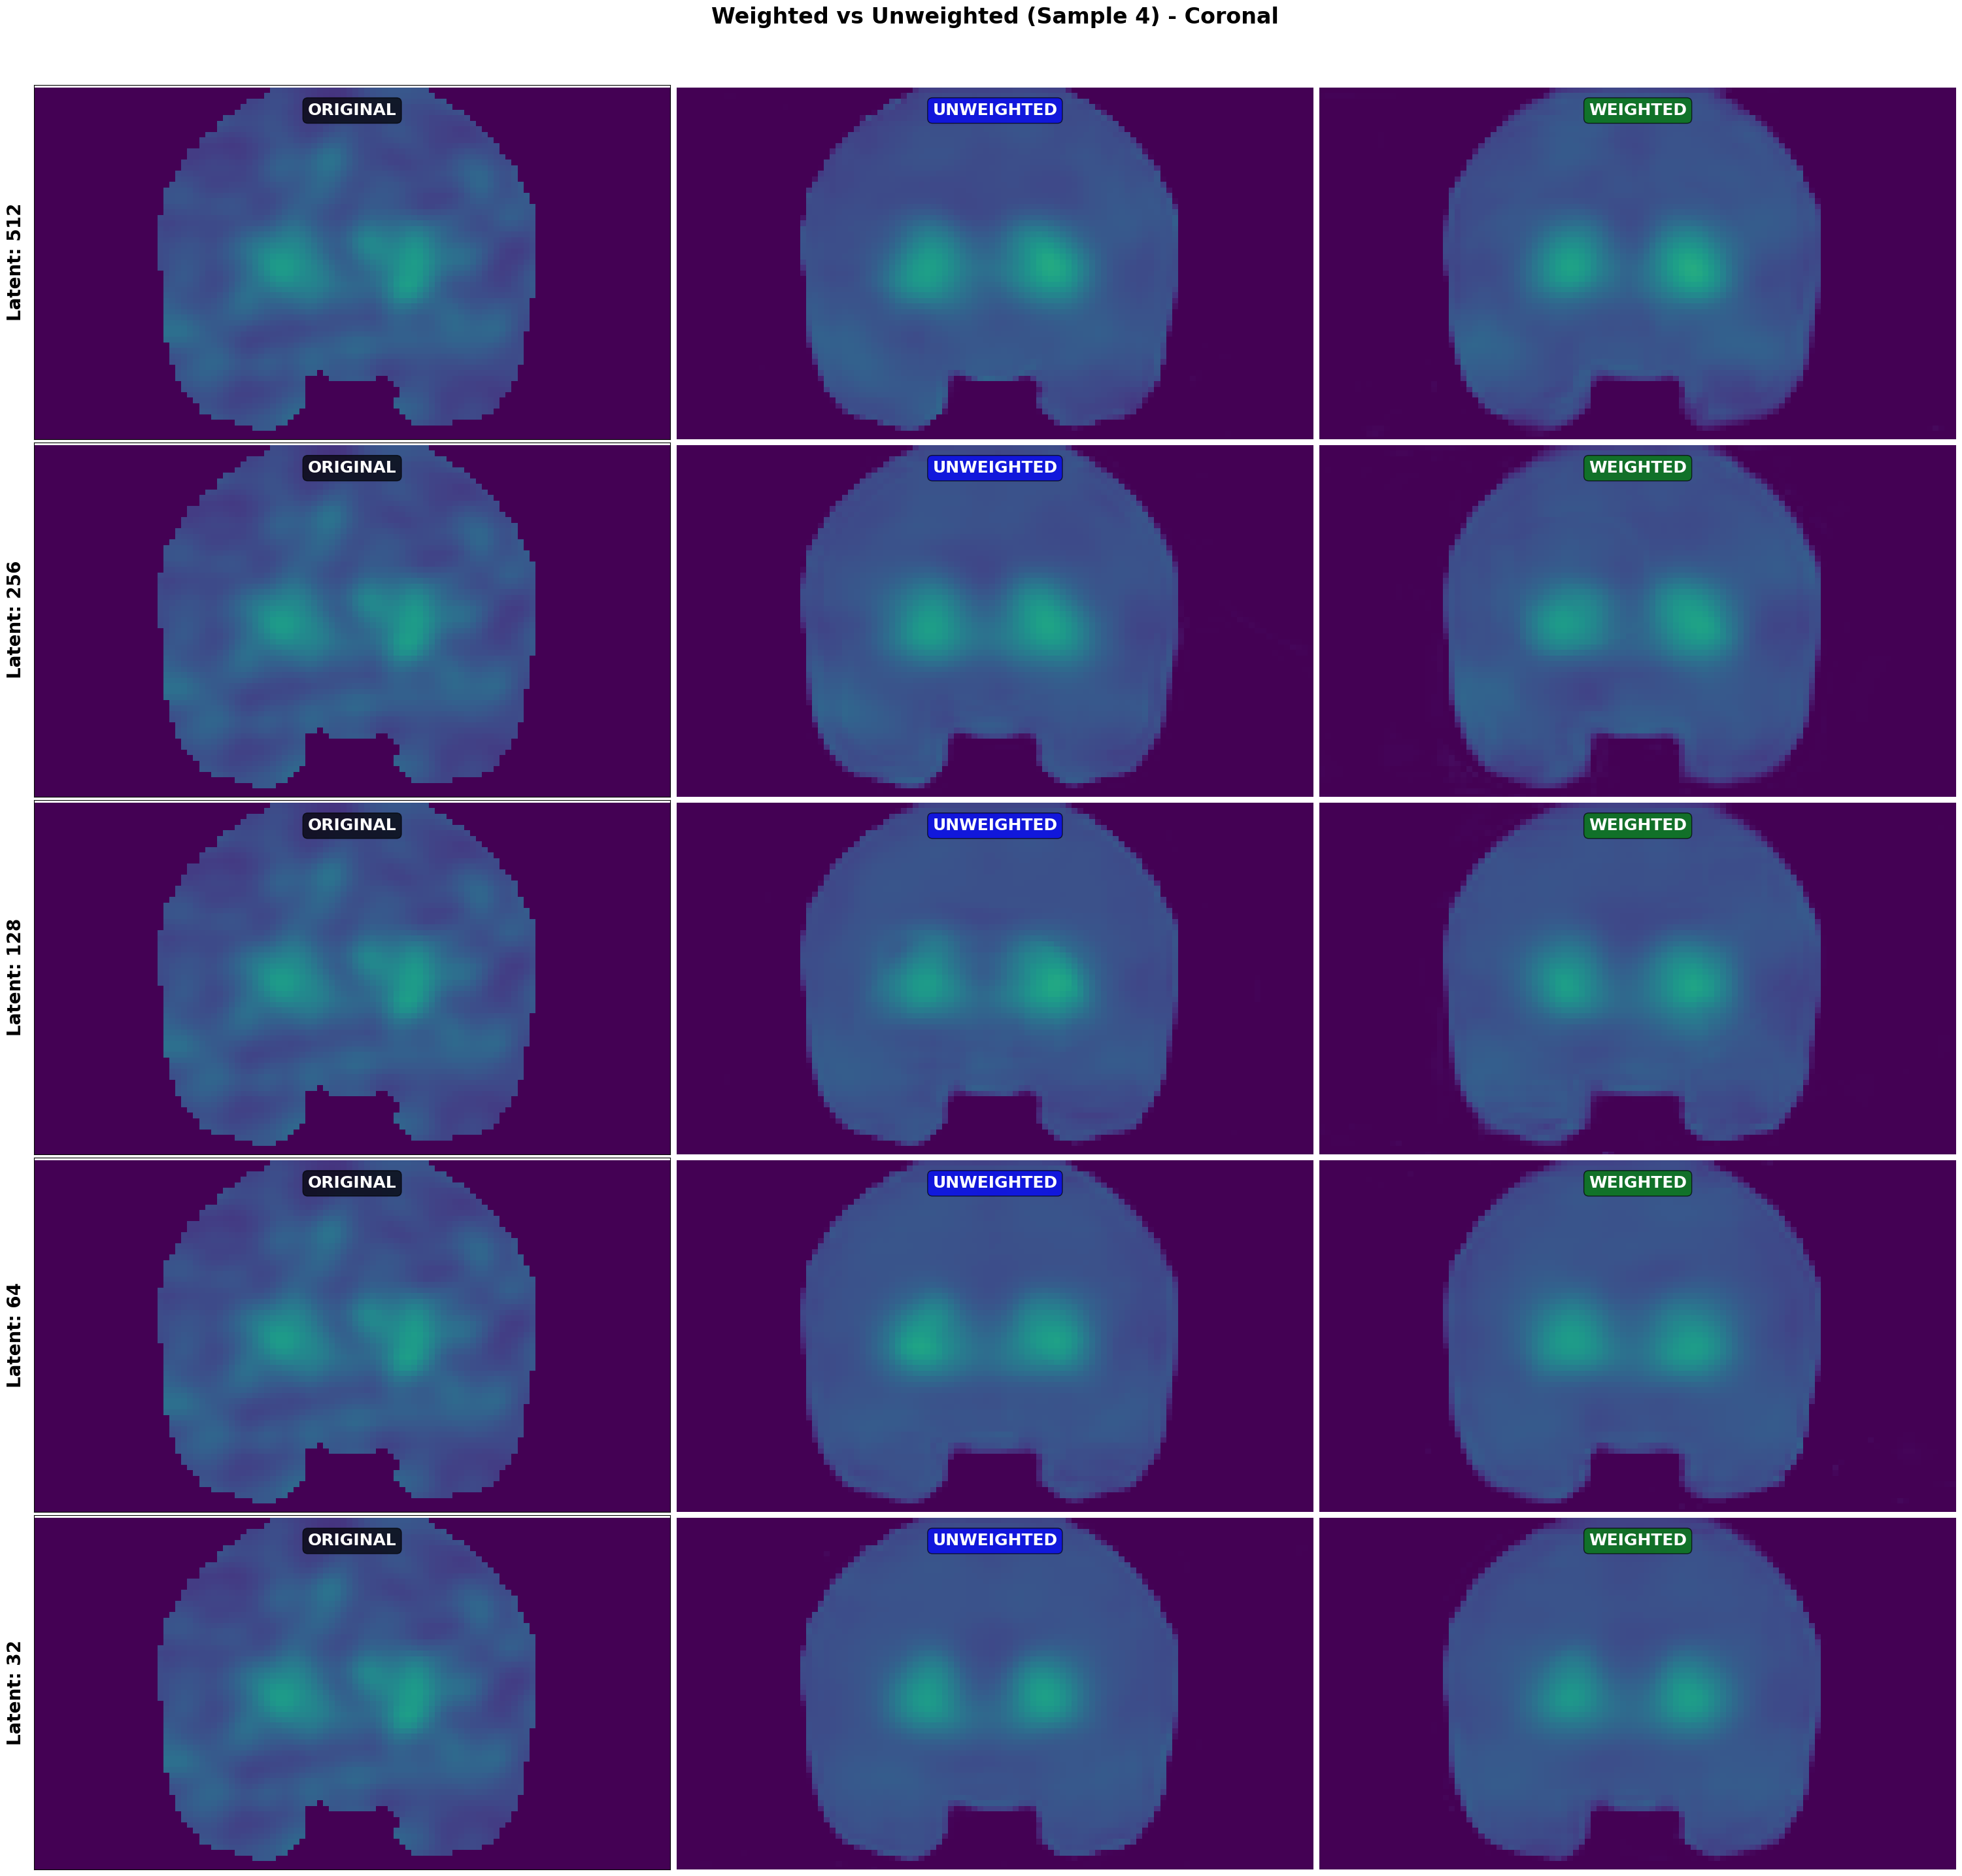

Coronal comparison visualizations saved to output/Experiments/WeightedUnweightedComparison


In [19]:
# Visualize side-by-side comparisons for each sample in batch
for pIdx in range(min(4, inp.shape[0])):
    
    num_rows = len(deconv_latent_dims)
    num_cols = 3
    
    # 1. OPTIMIZE FIGURE SIZE
    # Coronal views are often wider or shorter than axial views. 
    # We calculate height dynamically to prevent vertical white space.
    fig_width = 30
    # We multiply by 0.6 as a heuristic because coronal slices (Z-X) 
    # are often shorter than they are wide compared to axial. 
    # Adjust 0.6 to 1.0 if your images look too squashed.
    fig_height = (fig_width / num_cols) * num_rows * 0.6 
    
    fig = plt.figure(figsize=(fig_width, fig_height))
    
    # Loop through each latent dimension
    for col_idx, latent_dim in enumerate(deconv_latent_dims):
        unweighted_model_name = f"deconv_lat{latent_dim}"
        weighted_model_name = f"deconv_weighted_lat{latent_dim}"
        
        unweighted_recon = unweighted_reconstructions[unweighted_model_name]
        weighted_recon = weighted_reconstructions[weighted_model_name]
        
        # --- Original image ---
        ax = plt.subplot(num_rows, num_cols, col_idx * 3 + 1)
        # aspect='auto' is crucial here to fill the subplot rectangle completely
        ax.imshow(inp[pIdx, 0, :, 50, 10:-10].cpu(), cmap='viridis', vmin=-0., vmax=4., aspect='auto')
        ax.set_ylim(0, 64) # Preserving your specific Y-limit instruction

        # Label on Y-axis to save space
        ax.set_ylabel(f"Latent: {latent_dim}", fontsize=20, fontweight='bold', labelpad=10)

        # Add label on image
        ax.text(0.5, 0.95, "ORIGINAL", transform=ax.transAxes, fontsize=18, fontweight='bold',
               ha='center', va='top', color='white', bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
        
        # Remove ticks manually so we can keep the Y-label
        ax.set_xticks([])
        ax.set_yticks([])
        
        # --- Unweighted reconstruction ---
        ax = plt.subplot(num_rows, num_cols, col_idx * 3 + 2)
        ax.imshow(unweighted_recon[pIdx, 0, :, 50, 10:-10].cpu(), cmap='viridis', vmin=-0., vmax=4., aspect='auto')
        ax.set_ylim(0, 64)

        ax.text(0.5, 0.95, "UNWEIGHTED", transform=ax.transAxes, fontsize=18, fontweight='bold',
               ha='center', va='top', color='white', bbox=dict(boxstyle='round', facecolor='blue', alpha=0.7))
        ax.axis('off')
        
        # --- Weighted reconstruction ---
        ax = plt.subplot(num_rows, num_cols, col_idx * 3 + 3)
        ax.imshow(weighted_recon[pIdx, 0, :, 50, 10:-10].cpu(), cmap='viridis', vmin=-0., vmax=4., aspect='auto')
        ax.set_ylim(0, 64)

        ax.text(0.5, 0.95, "WEIGHTED", transform=ax.transAxes, fontsize=18, fontweight='bold',
               ha='center', va='top', color='white', bbox=dict(boxstyle='round', facecolor='green', alpha=0.7))
        ax.axis('off')
    
    # 2. REMOVE MARGINS
    # Push images to the edge of the figure
    plt.subplots_adjust(wspace=0.01, hspace=0.01, left=0.01, right=0.99, bottom=0.01, top=0.92)

    plt.suptitle(f"Weighted vs Unweighted (Sample {pIdx + 1}) - Coronal", 
                 fontsize=24, fontweight='bold', y=0.96)
    
    # tight_layout is removed to prevent it from overriding our custom margins
    plt.savefig(os.path.join(comparison_output_dir, f"comparison_coronal_sample_{pIdx+1}.png"), dpi=150, bbox_inches='tight')
    plt.show()

print(f"Coronal comparison visualizations saved to {comparison_output_dir}")

## Difference Maps - Axial

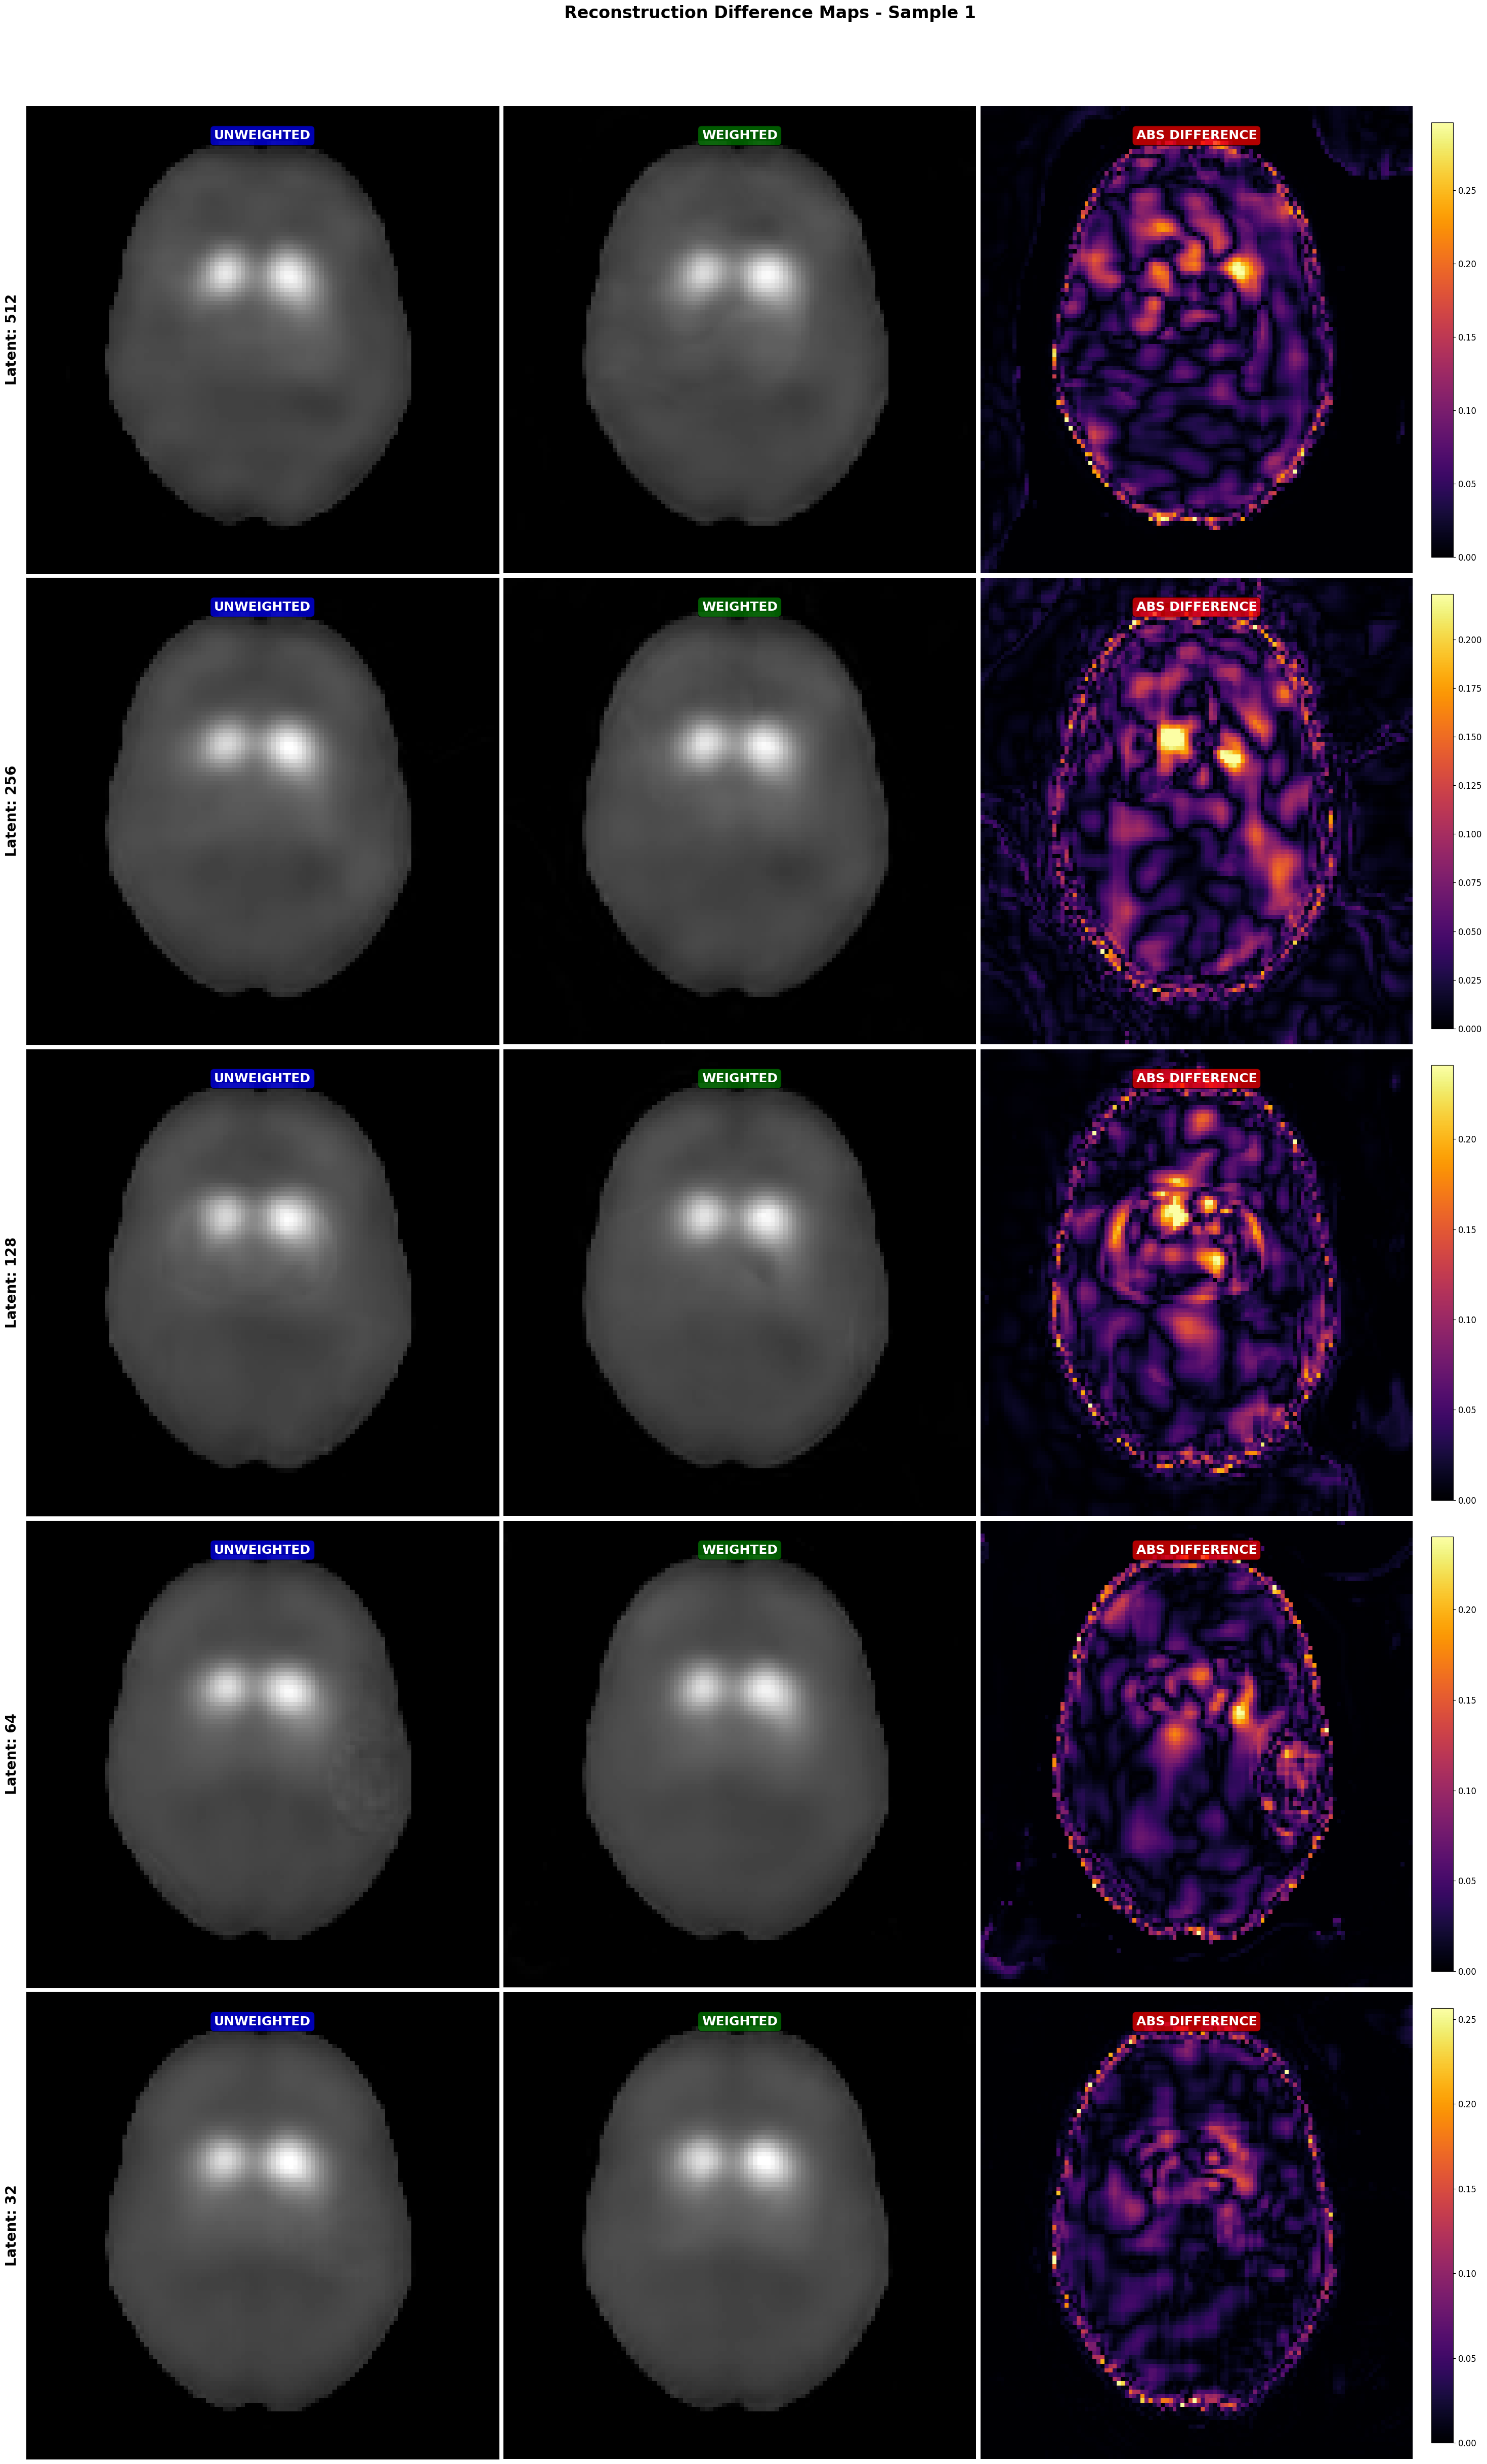

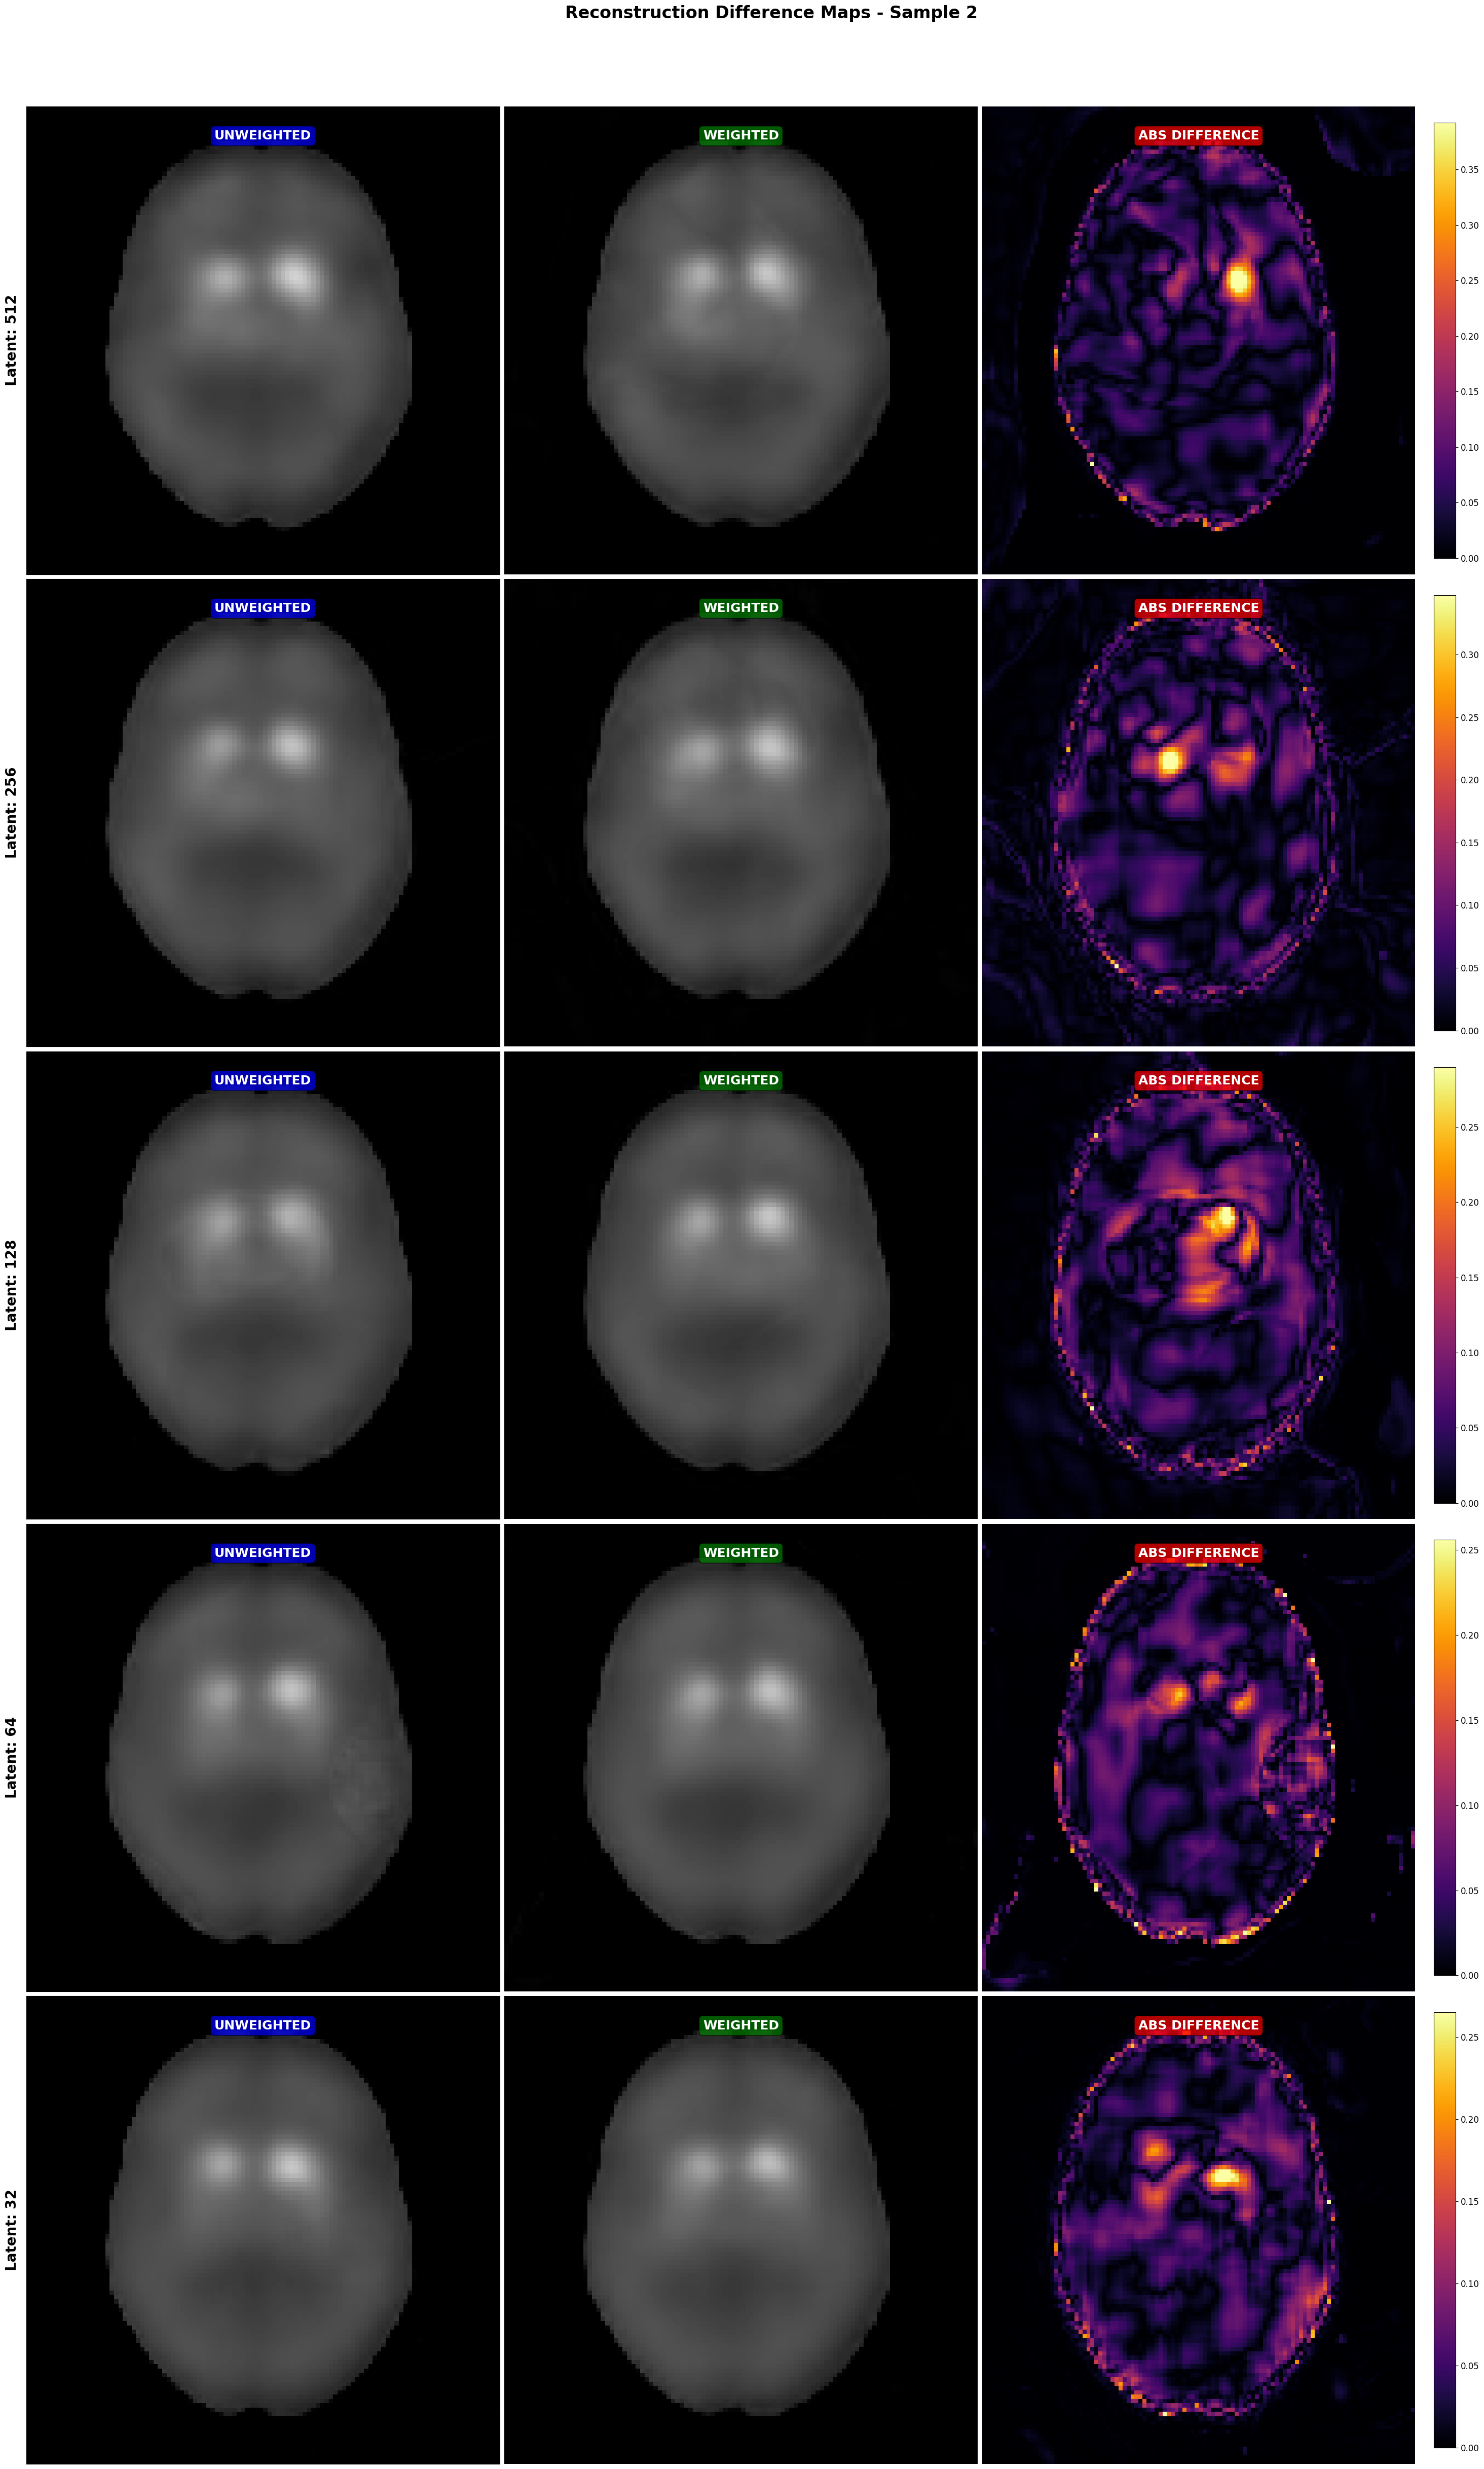

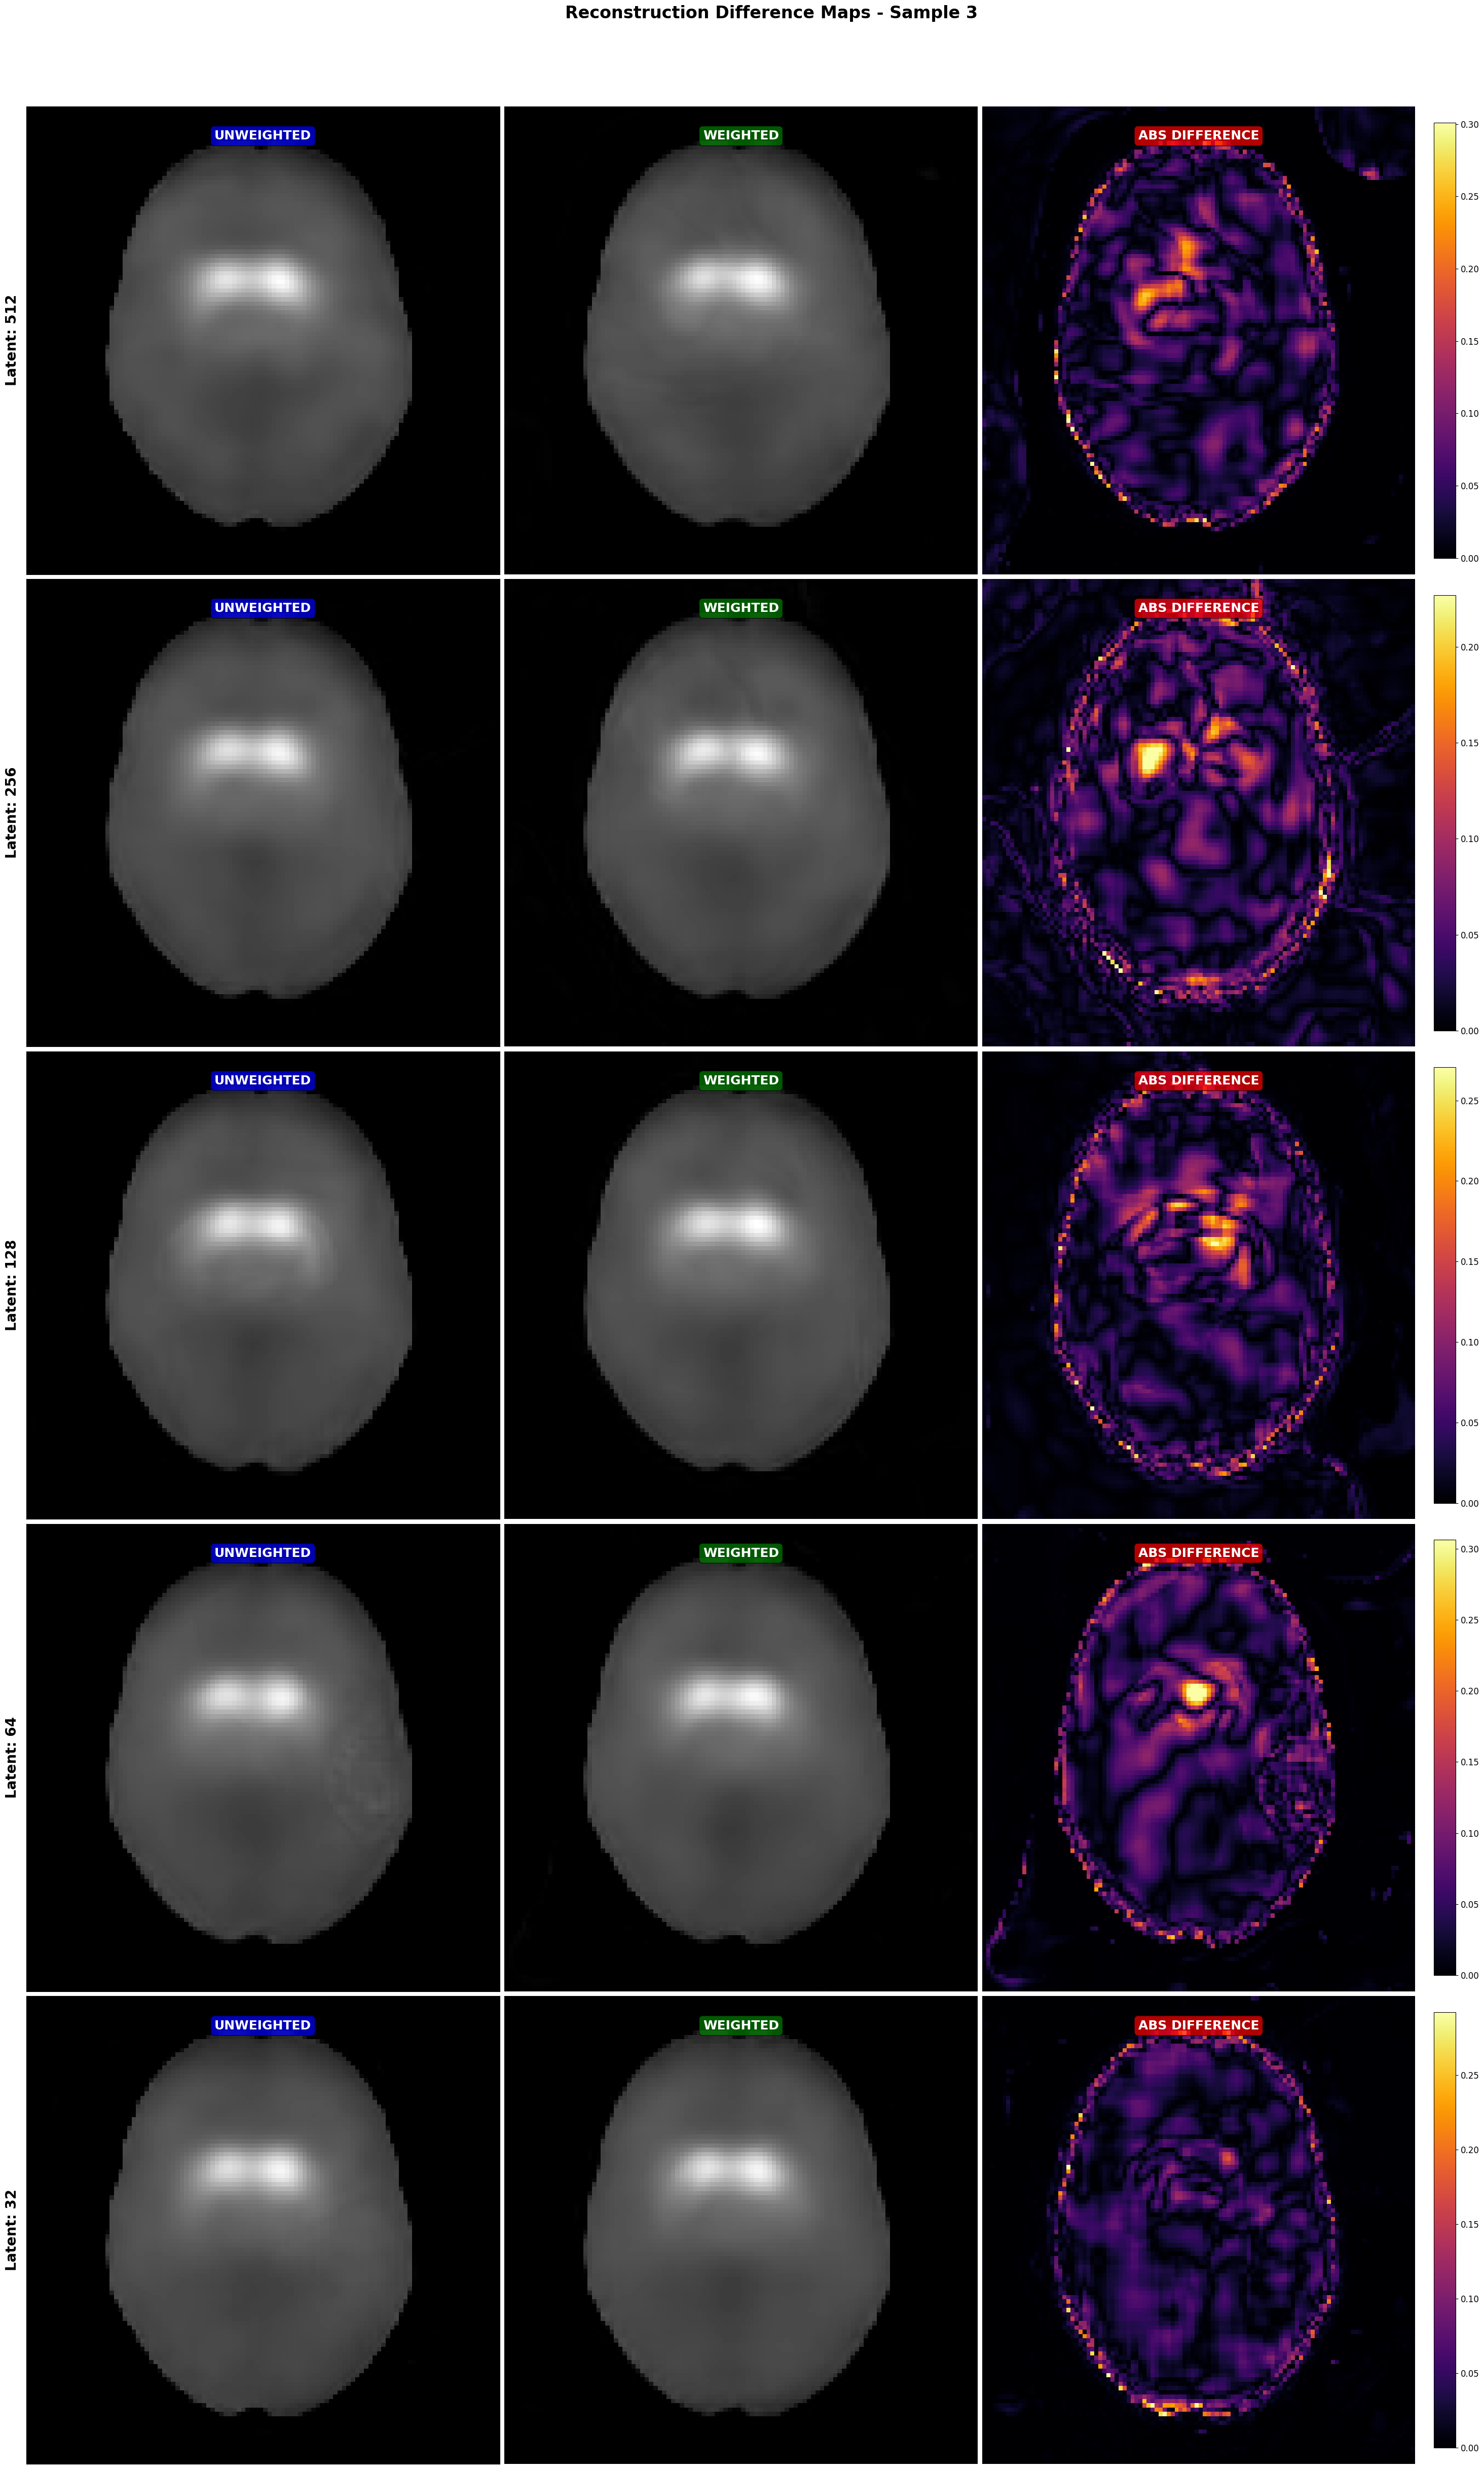

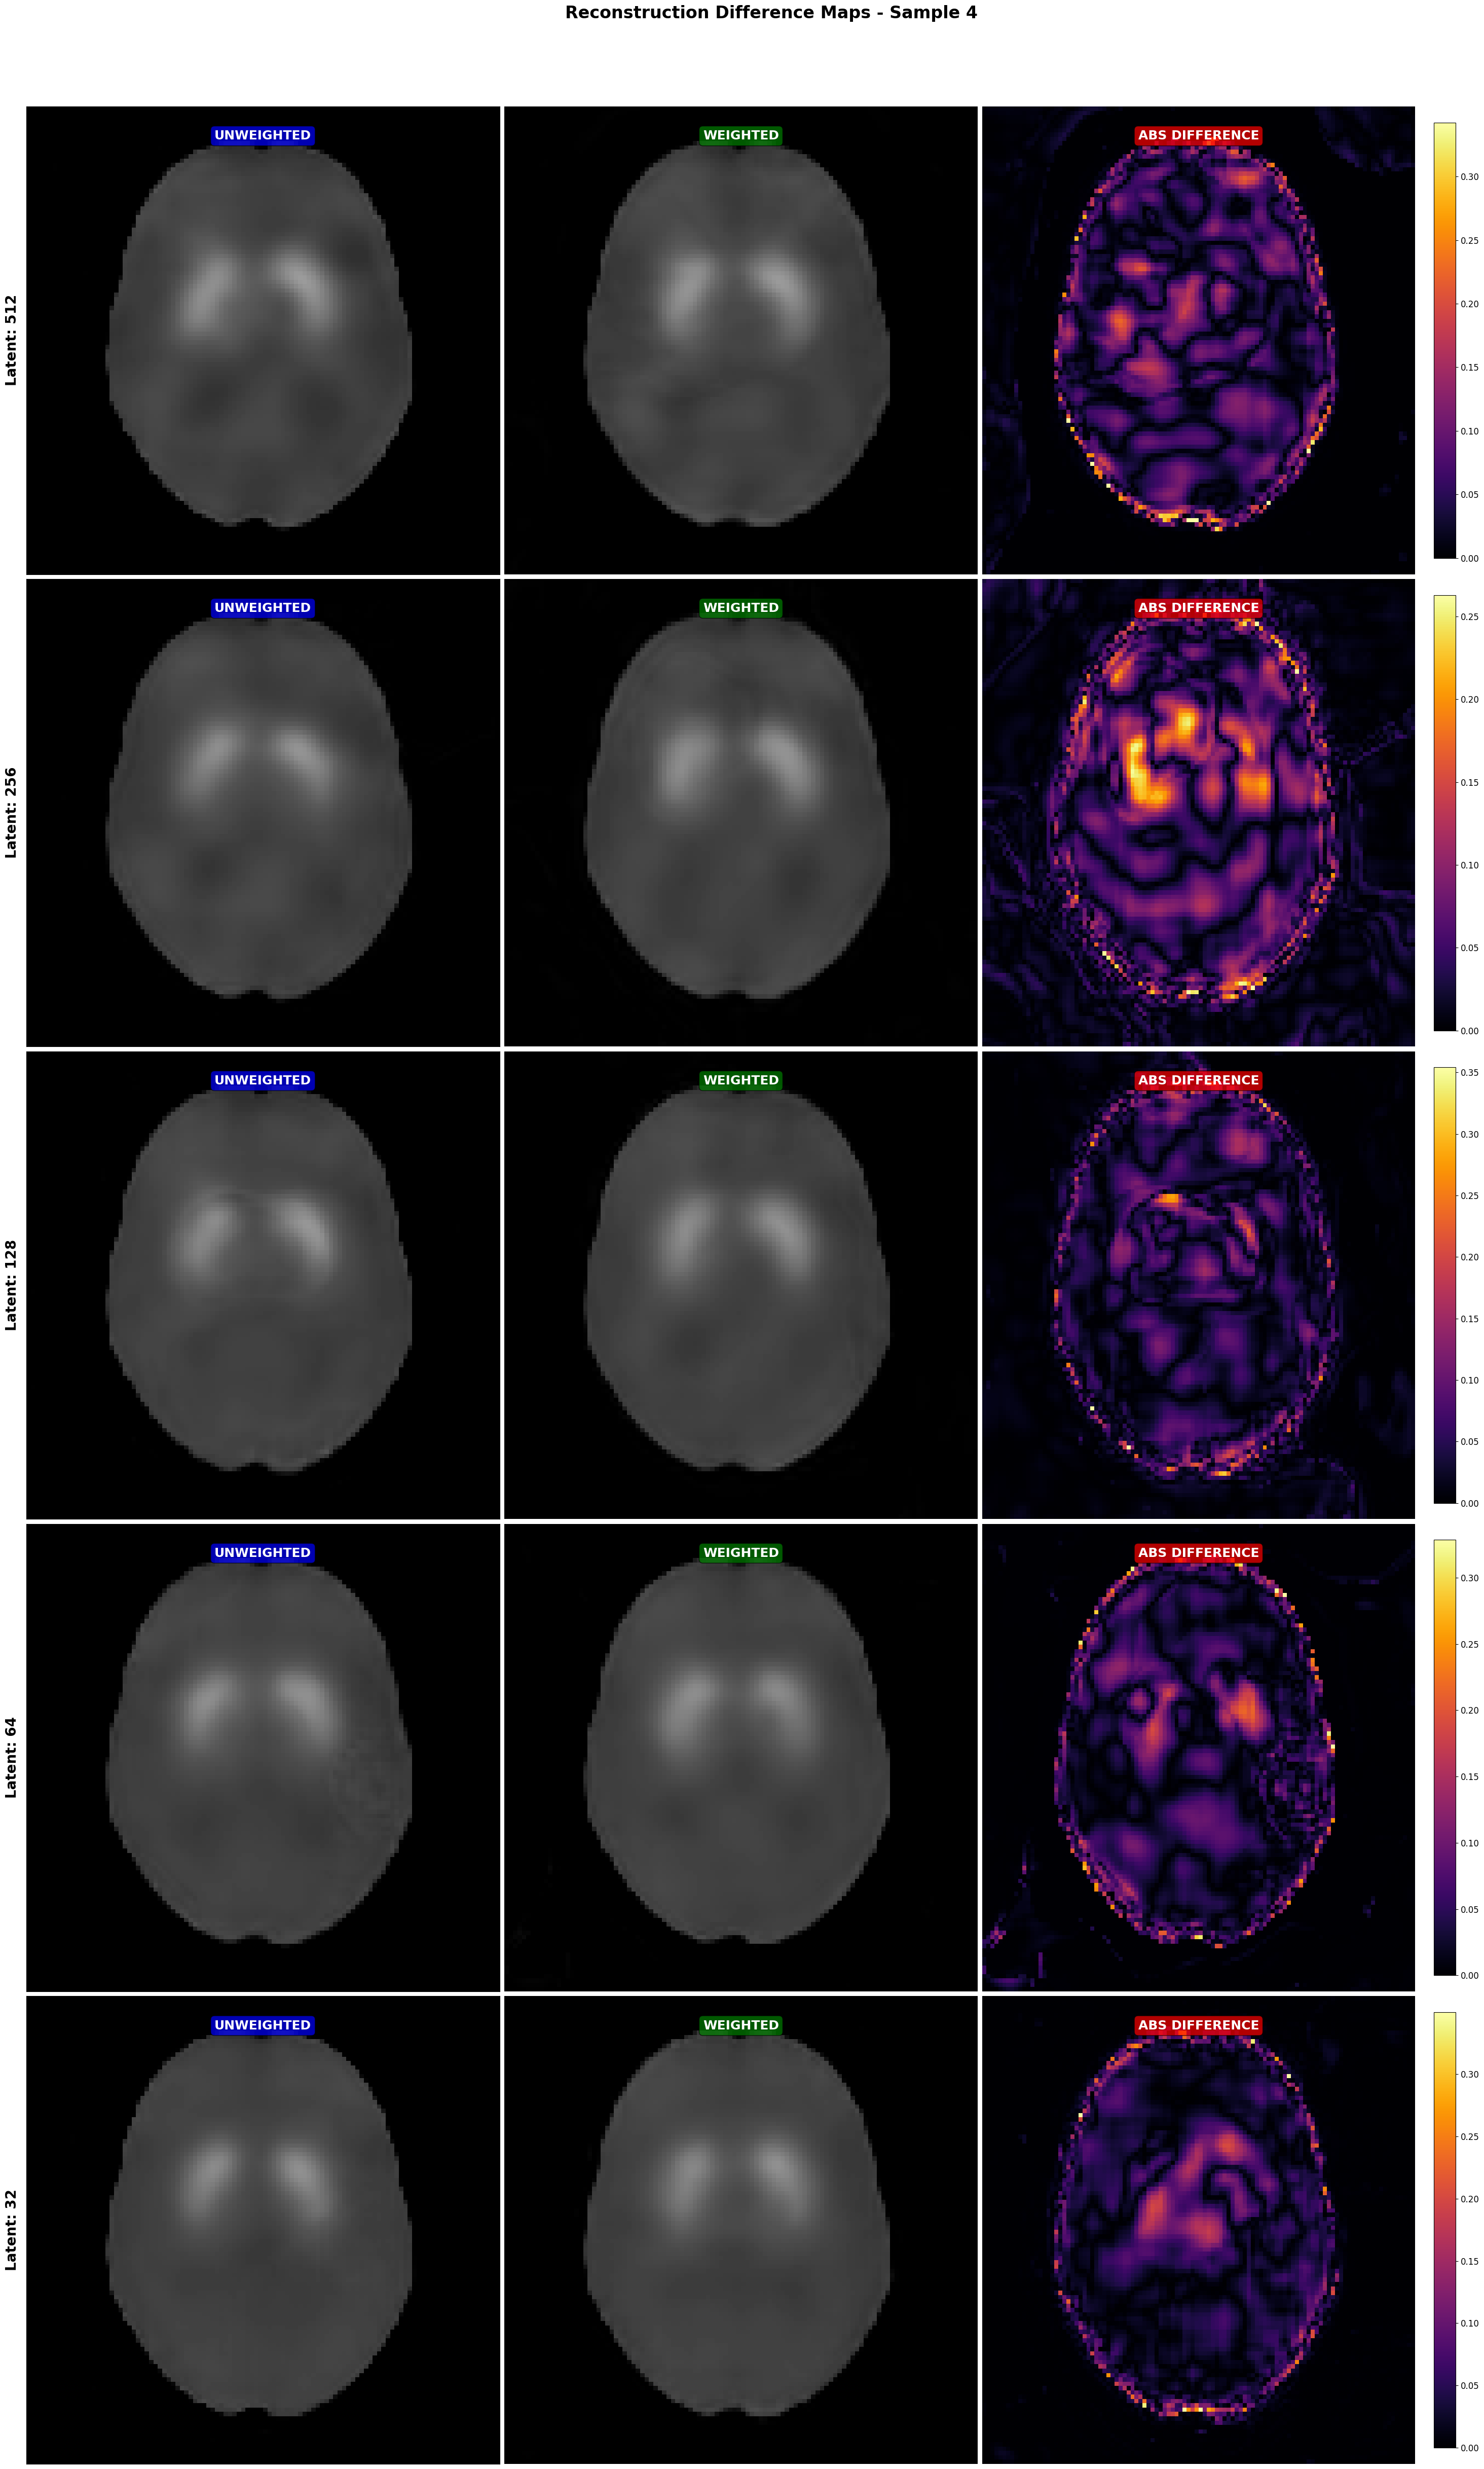

Difference map visualizations saved to output/Experiments/WeightedUnweightedComparison


In [20]:
# Visualize difference maps between weighted and unweighted reconstructions
for pIdx in range(min(4, inp.shape[0])):
    
    num_rows = len(deconv_latent_dims)
    num_cols = 3 # Changed to 3 columns: Unweighted | Weighted | Difference
    
    # 1. DYNAMIC FIGURE SIZE
    fig_width = 30
    fig_height = (fig_width / num_cols) * num_rows
    
    fig = plt.figure(figsize=(fig_width, fig_height))
    
    # Loop through each latent dimension
    for col_idx, latent_dim in enumerate(deconv_latent_dims):
        unweighted_model_name = f"deconv_lat{latent_dim}"
        weighted_model_name = f"deconv_weighted_lat{latent_dim}"
        
        unweighted_recon = unweighted_reconstructions[unweighted_model_name]
        weighted_recon = weighted_reconstructions[weighted_model_name]
        
        # Calculate Difference (Absolute)
        # We slice first to ensure calculations are done on the 2D plane
        slice_unweighted = unweighted_recon[pIdx, 0, 32, 10:-10, 10:-10].cpu()
        slice_weighted = weighted_recon[pIdx, 0, 32, 10:-10, 10:-10].cpu()
        diff = torch.abs(slice_weighted - slice_unweighted)
        
        # --- Column 1: Unweighted Reconstruction ---
        ax = plt.subplot(num_rows, num_cols, col_idx * 3 + 1)
        ax.imshow(slice_unweighted, cmap='gray', vmin=-0., vmax=4., aspect='auto')
        
        ax.set_ylabel(f"Latent: {latent_dim}", fontsize=20, fontweight='bold', labelpad=10)
        ax.text(0.5, 0.95, "UNWEIGHTED", transform=ax.transAxes, fontsize=18, fontweight='bold',
               ha='center', va='top', color='white', bbox=dict(boxstyle='round', facecolor='blue', alpha=0.7))
        ax.set_xticks([])
        ax.set_yticks([])

        # --- Column 2: Weighted Reconstruction (Added for Context) ---
        ax = plt.subplot(num_rows, num_cols, col_idx * 3 + 2)
        ax.imshow(slice_weighted, cmap='gray', vmin=-0., vmax=4., aspect='auto')
        
        ax.text(0.5, 0.95, "WEIGHTED", transform=ax.transAxes, fontsize=18, fontweight='bold',
               ha='center', va='top', color='white', bbox=dict(boxstyle='round', facecolor='green', alpha=0.7))
        ax.axis('off')

        # --- Column 3: Difference Map ---
        ax = plt.subplot(num_rows, num_cols, col_idx * 3 + 3)
        # 'inferno' or 'magma' are often better than 'hot' for perception, but 'hot' is fine too
        # logical max for diff helps contrast
        vmax_diff = diff.max() * 0.8 if diff.max() > 0 else 1.0 
        im = ax.imshow(diff, cmap='inferno', vmin=0., vmax=vmax_diff, aspect='auto')

        ax.text(0.5, 0.95, "ABS DIFFERENCE", transform=ax.transAxes, fontsize=18, fontweight='bold',
               ha='center', va='top', color='white', bbox=dict(boxstyle='round', facecolor='red', alpha=0.7))
        ax.axis('off')
        
        # Add colorbar ONLY to the difference map
        # We add it to every row to ensure the "Difference" image size matches the others
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=12)
    
    # 2. REMOVE WHITE SPACE
    plt.subplots_adjust(wspace=0.01, hspace=0.01, left=0.01, right=0.95, bottom=0.01, top=0.94)
    
    plt.suptitle(f"Reconstruction Difference Maps - Sample {pIdx + 1}", 
                 fontsize=24, fontweight='bold', y=0.98)
    
    plt.savefig(os.path.join(comparison_output_dir, f"difference_axial_sample_{pIdx+1}.png"), dpi=150, bbox_inches='tight')
    plt.show()

print(f"Difference map visualizations saved to {comparison_output_dir}")